# Feature Importance Analysis

Loads the **best XGBoost model per target** from the Phase 7 broad sweep (288 combos × 8 targets), pulls the logged `feature_importance.csv` from MLflow, and generates cross-target insights.

**Model selection**: same logic as `prediction_inspection.ipynb` — best run per per-target broad-sweep experiment, ranked by primary metric (log-loss for classifiers, `mae_test` for regressors).

**Targets covered**: `result_3way`, `btts`, `home_goals`, `away_goals`, `total_goals`, `home_corners`, `away_corners`, `total_corners`

In [64]:
from __future__ import annotations

import tempfile
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
import yaml
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
shap.initjs()
sns.set_theme(style="whitegrid", palette="muted")

# ── paths ──────────────────────────────────────────────────────────────────
def _find_config(start: Path) -> Path:
    for parent in [start] + list(start.parents):
        candidate = parent / "config.yaml"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("config.yaml not found")

CONFIG_PATH = _find_config(Path.cwd())
REPO_ROOT = CONFIG_PATH.parent

with CONFIG_PATH.open() as fh:
    _cfg = yaml.safe_load(fh) or {}

db_rel = Path(_cfg.get("paths", {}).get("database_path", "data/fpai_core.db"))
DB_PATH = db_rel if db_rel.is_absolute() else REPO_ROOT / db_rel

SCHEMA_PATH = REPO_ROOT / "config" / "schema.yaml"
with SCHEMA_PATH.open() as fh:
    _schema = yaml.safe_load(fh) or {}
ALL_FEATURES = _schema.get("training_setup", {}).get("selected_features", [])

TRAINING_CUTOFF = pd.Timestamp("2024-04-03")

mlflow.set_tracking_uri(str(REPO_ROOT / "mlruns"))

print(f"Repo root       : {REPO_ROOT}")
print(f"DB path         : {DB_PATH}")
print(f"MLflow URI      : {mlflow.get_tracking_uri()}")
print(f"Schema features : {len(ALL_FEATURES)}")
print(f"SHAP version    : {shap.__version__}")

Repo root       : /Users/tianqihuang/Documents/GitHub/FPAI
DB path         : /Users/tianqihuang/Documents/GitHub/FPAI/data/fpai_core.db
MLflow URI      : /Users/tianqihuang/Documents/GitHub/FPAI/mlruns
Schema features : 159
SHAP version    : 0.51.0


In [65]:
# ── load feature store + raw match data ───────────────────────────────────
with duckdb.connect(str(DB_PATH), read_only=True) as conn:
    raw = conn.execute("""
        SELECT r.match_id, r.date, r.home_team, r.away_team,
               r.fthg, r.ftag, r.hc, r.ac,
               f.*
        FROM raw_matches r
        INNER JOIN feature_store f ON r.match_id = f.match_id
        WHERE r.league = 'E0'
        ORDER BY r.date
    """).fetchdf()

raw["date"] = pd.to_datetime(raw["date"])
for col in ["fthg", "ftag", "hc", "ac"]:
    raw[col] = pd.to_numeric(raw[col], errors="coerce")

raw["split"] = np.where(raw["date"] > TRAINING_CUTOFF, "test", "train")

# ── target label series (indexed same as raw) ─────────────────────────────
def _result(row):
    if row.fthg > row.ftag:
        return "home"
    if row.fthg == row.ftag:
        return "draw"
    return "away"

TARGET_LABELS = {
    "result_3way": raw.apply(_result, axis=1),
    "btts":        ((raw["fthg"] > 0) & (raw["ftag"] > 0)).astype(int),
    "home_goals":  raw["fthg"],
    "away_goals":  raw["ftag"],
    "total_goals": raw["fthg"] + raw["ftag"],
    "home_corners":raw["hc"],
    "away_corners":raw["ac"],
    "total_corners":raw["hc"] + raw["ac"],
}

# ── feature columns present in feature store ──────────────────────────────
FEATURE_COLS = [f for f in ALL_FEATURES if f in raw.columns]
missing = set(ALL_FEATURES) - set(FEATURE_COLS)
print(f"Rows loaded         : {len(raw):,}  (train={( raw.split=='train').sum():,}  test={(raw.split=='test').sum():,})")
print(f"Feature cols usable : {len(FEATURE_COLS)}/{len(ALL_FEATURES)}")
if missing:
    print(f"Missing from store  : {sorted(missing)}")

Rows loaded         : 3,721  (train=2,961  test=760)
Feature cols usable : 159/159


## 1. Model Selection & SHAP Computation

For each target, the best run is retrieved from its per-target broad-sweep MLflow experiment (same selection logic as `prediction_inspection.ipynb`). The best hyperparameters are then used to **retrain** one XGBoost model on the training split. SHAP values are computed on the held-out test split using `shap.TreeExplainer`.

Feature importance = **mean |SHAP value|** across all test rows — this is model-agnostic and reflects the actual average impact on the model output, not XGBoost's internal gain heuristic.

| Target group | Experiment | Selection metric |
|---|---|---|
| Classifiers | `FPAI_<target>_xgboost_broad_v1` | `test_log_loss` ↓ |
| Regressors | `FPAI_<target>_xgboost_regressor_broad_v1` | `mae_test` ↓ |

In [66]:
# ── experiment + task config per target ───────────────────────────────────
TARGET_CONFIG = {
    "result_3way": {
        "experiment":    "FPAI_result_3way_xgboost_broad_v1",
        "sort_metric":   "test_log_loss",
        "ascending":     True,
        "primary_label": "Log-loss",
        "task":          "multiclass",
        "prd": {"metric": "accuracy_val", "threshold": 0.60, "direction": "ge"},
    },
    "btts": {
        "experiment":    "FPAI_btts_xgboost_broad_v1",
        "sort_metric":   "test_log_loss",
        "ascending":     True,
        "primary_label": "Log-loss",
        "task":          "binary",
        "prd": {"metric": "test_log_loss", "threshold": 0.68, "direction": "le"},
    },
    "home_goals": {
        "experiment":    "FPAI_home_goals_xgboost_regressor_broad_v1",
        "sort_metric":   "mae_test",
        "ascending":     True,
        "primary_label": "MAE",
        "task":          "regression",
        "prd": {"metric": "mae_test", "threshold": 0.50, "direction": "lt"},
    },
    "away_goals": {
        "experiment":    "FPAI_away_goals_xgboost_regressor_broad_v1",
        "sort_metric":   "mae_test",
        "ascending":     True,
        "primary_label": "MAE",
        "task":          "regression",
        "prd": {"metric": "mae_test", "threshold": 0.50, "direction": "lt"},
    },
    "total_goals": {
        "experiment":    "FPAI_total_goals_xgboost_regressor_broad_v1",
        "sort_metric":   "mae_test",
        "ascending":     True,
        "primary_label": "MAE",
        "task":          "regression",
        "prd": {"metric": "mae_test", "threshold": 0.75, "direction": "lt"},
    },
    "home_corners": {
        "experiment":    "FPAI_home_corners_xgboost_regressor_broad_v1",
        "sort_metric":   "mae_test",
        "ascending":     True,
        "primary_label": "MAE",
        "task":          "regression",
        "prd": {"metric": "mae_test", "threshold": 1.50, "direction": "lt"},
    },
    "away_corners": {
        "experiment":    "FPAI_away_corners_xgboost_regressor_broad_v1",
        "sort_metric":   "mae_test",
        "ascending":     True,
        "primary_label": "MAE",
        "task":          "regression",
        "prd": {"metric": "mae_test", "threshold": 1.50, "direction": "lt"},
    },
    "total_corners": {
        "experiment":    "FPAI_total_corners_xgboost_regressor_broad_v1",
        "sort_metric":   "mae_test",
        "ascending":     True,
        "primary_label": "MAE",
        "task":          "regression",
        "prd": {"metric": "mae_test", "threshold": 1.50, "direction": "lt"},
    },
}

TARGETS_ORDER = [
    "result_3way", "btts",
    "home_goals", "away_goals", "total_goals",
    "home_corners", "away_corners", "total_corners",
]

print(f"Targets configured: {len(TARGET_CONFIG)}")

Targets configured: 8


In [67]:
# ── retrain best model per target → compute SHAP on test split ────────────
_repo_root = next(
    p for p in [Path.cwd()] + list(Path.cwd().parents)
    if (p / "config.yaml").exists()
)
mlflow.set_tracking_uri(str(_repo_root / "mlruns"))
client = mlflow.tracking.MlflowClient()

X_all = raw[FEATURE_COLS].copy()
X_all = X_all.fillna(X_all.mean())

best_runs:          dict[str, dict]       = {}
feature_importance: dict[str, pd.DataFrame] = {}
shap_store:         dict[str, dict]       = {}

def _mean_abs_shap(sv) -> np.ndarray:
    """Return mean |SHAP| per feature, handling regression / binary / multiclass."""
    if isinstance(sv, list):
        return np.mean([np.abs(a).mean(axis=0) for a in sv], axis=0)
    if sv.ndim == 3:
        return np.abs(sv).mean(axis=(0, 2))
    return np.abs(sv).mean(axis=0)

for target, cfg in TARGET_CONFIG.items():
    try:
        exp = client.get_experiment_by_name(cfg["experiment"])
        if exp is None:
            print(f"  {target}: experiment not found"); continue

        order = f"metrics.{cfg['sort_metric']} {'ASC' if cfg['ascending'] else 'DESC'}"
        runs = client.search_runs([exp.experiment_id], max_results=1, order_by=[order])
        if not runs:
            print(f"  {target}: no runs"); continue

        r = runs[0]
        p = r.data.params
        primary_val = r.data.metrics.get(cfg["sort_metric"], float("nan"))

        best_runs[target] = {
            "run_id": r.info.run_id,
            "primary_metric": cfg["primary_label"],
            "primary_value": primary_val,
            "params": p,
            "metrics": r.data.metrics,
            "prd": cfg["prd"],
        }

        y_full = TARGET_LABELS[target]
        valid  = y_full.notna()
        mask_tr = (raw["split"] == "train") & valid
        mask_te = (raw["split"] == "test")  & valid

        X_tr, y_tr = X_all.loc[mask_tr], y_full.loc[mask_tr]
        X_te       = X_all.loc[mask_te]
        y_te_orig  = y_full.loc[mask_te]   # original labels, always stored

        label_encoder = None
        if cfg["task"] == "multiclass":
            label_encoder = LabelEncoder()
            y_tr_enc = label_encoder.fit_transform(y_tr)
            y_te_enc = label_encoder.transform(y_te_orig)
        else:
            y_tr_enc = y_tr.values
            y_te_enc = y_te_orig.values

        xgb_kw = dict(
            n_estimators     = int(p.get("n_estimators", 300)),
            max_depth        = int(p.get("max_depth", 4)),
            learning_rate    = float(p.get("learning_rate", 0.05)),
            subsample        = float(p.get("subsample", 0.8)),
            colsample_bytree = float(p.get("colsample_bytree", 0.8)),
            min_child_weight = int(p.get("min_child_weight", 5)),
            reg_alpha        = float(p.get("reg_alpha", 0.0)),
            reg_lambda       = float(p.get("reg_lambda", 1.0)),
            tree_method      = "hist",
            random_state     = 42,
            n_jobs           = -1,
        )

        if cfg["task"] == "multiclass":
            n_cls = len(label_encoder.classes_)
            model = xgb.XGBClassifier(objective="multi:softprob", num_class=n_cls,
                                       eval_metric="mlogloss", **xgb_kw)
        elif cfg["task"] == "binary":
            model = xgb.XGBClassifier(objective="binary:logistic",
                                       eval_metric="logloss", **xgb_kw)
        else:
            model = xgb.XGBRegressor(
                objective=p.get("objective", "reg:squarederror"), **xgb_kw)

        model.fit(X_tr, y_tr_enc, verbose=False)

        explainer = shap.TreeExplainer(model)
        shap_vals = explainer.shap_values(X_te)
        mean_shap = _mean_abs_shap(shap_vals)

        fi = pd.DataFrame({"feature": FEATURE_COLS, "importance": mean_shap})
        fi = fi.sort_values("importance", ascending=False).reset_index(drop=True)
        fi["rank"]   = range(1, len(fi) + 1)
        fi["target"] = target
        feature_importance[target] = fi

        shap_store[target] = {
            "shap_values":   shap_vals,
            "X_test":        X_te,
            "feature_cols":  FEATURE_COLS,
            "label_encoder": label_encoder,
            "task":          cfg["task"],
            "model":         model,
            "y_test_orig":   y_te_orig,   # for error computation
            "y_test_enc":    y_te_enc,
            "match_meta":    raw.loc[mask_te, ["home_team", "away_team", "fthg", "ftag", "date"]].reset_index(drop=True),
        }

        print(f"  {target}: {cfg['primary_label']}={primary_val:.4f}  "
              f"test_n={len(X_te)}  top_feat={fi['feature'].iloc[0]}")

    except Exception as exc:
        import traceback
        print(f"  {target}: ERROR — {type(exc).__name__}: {exc}")
        traceback.print_exc()

print(f"\nLoaded SHAP for {len(feature_importance)}/{len(TARGET_CONFIG)} targets")

  result_3way: Log-loss=1.0025  test_n=760  top_feat=MKT_IMPLIED_HOME
  btts: Log-loss=0.6847  test_n=760  top_feat=MKT_OVERROUND
  home_goals: MAE=0.9400  test_n=760  top_feat=MKT_IMPLIED_HOME
  away_goals: MAE=0.8267  test_n=760  top_feat=MKT_IMPLIED_AWAY
  total_goals: MAE=1.2824  test_n=760  top_feat=MKT_IMPLIED_OVER25
  home_corners: MAE=2.1393  test_n=760  top_feat=MKT_LOG_ODDS_H_A_RATIO
  away_corners: MAE=2.0814  test_n=760  top_feat=MKT_IMPLIED_AWAY
  total_corners: MAE=2.6629  test_n=760  top_feat=MKT_IMPLIED_UNDER25

Loaded SHAP for 8/8 targets


In [68]:
# ── selection summary table ───────────────────────────────────────────────
if not best_runs:
    print("No models loaded — re-run the cell above and check for errors.")
else:
    rows = []
    for target in TARGETS_ORDER:
        if target not in best_runs:
            continue
        info = best_runs[target]
        prd = info["prd"]
        prd_val = info["metrics"].get(prd["metric"], float("nan"))
        if not np.isnan(prd_val):
            if prd["direction"] == "ge":
                prd_met = "PASS" if prd_val >= prd["threshold"] else "FAIL"
            elif prd["direction"] == "le":
                prd_met = "PASS" if prd_val <= prd["threshold"] else "FAIL"
            else:
                prd_met = "PASS" if prd_val < prd["threshold"] else "FAIL"
        else:
            prd_met = "N/A"

        rows.append({
            "Target": target,
            "Run ID (short)": info["run_id"][:8] + "…",
            "Primary Metric": info["primary_metric"],
            "Best Value": f"{info['primary_value']:.4f}",
            "PRD Check": f"{prd['metric']} {prd['direction']} {prd['threshold']}",
            "PRD Met": prd_met,
            "n_estimators": info["params"].get("n_estimators", "—"),
            "max_depth": info["params"].get("max_depth", "—"),
            "learning_rate": info["params"].get("learning_rate", "—"),
        })

    sel_df = pd.DataFrame(rows)
    print("Best model per target (Phase 7 broad sweep):\n")
    display(sel_df.set_index("Target"))

Best model per target (Phase 7 broad sweep):



,Run ID (short),Primary Metric,Best Value,PRD Check,PRD Met,n_estimators,max_depth,learning_rate
Target,,,,,,,,
result_3way,626f0a91…,Log-loss,1.0025,accuracy_val ge 0.6,FAIL,800,2,0.1
btts,11a5cd61…,Log-loss,0.6847,test_log_loss le 0.68,FAIL,300,2,0.01
home_goals,90118698…,MAE,0.9400,mae_test lt 0.5,FAIL,300,2,0.01
away_goals,0cc997ca…,MAE,0.8267,mae_test lt 0.5,FAIL,300,2,0.01
total_goals,b3e63e6f…,MAE,1.2824,mae_test lt 0.75,FAIL,300,2,0.01
home_corners,94555e41…,MAE,2.1393,mae_test lt 1.5,FAIL,300,2,0.01
away_corners,02346d45…,MAE,2.0814,mae_test lt 1.5,FAIL,800,3,0.1
total_corners,fb421d37…,MAE,2.6629,mae_test lt 1.5,FAIL,300,2,0.01


## 2. Feature Group Taxonomy

Features are grouped by their prefix into interpretable families. This is used throughout subsequent analyses.

In [69]:
# ── feature group taxonomy ────────────────────────────────────────────────
GROUP_MAP = {
    "MKT": "Market / Odds",
    "OFF": "Offensive Stats",
    "DEF": "Defensive Stats",
    "OPP": "Opponent-Adjusted",
    "EFFICIENCY": "Efficiency Ratios",
    "INTERACTION": "Interaction Terms",
    "DIS": "Discipline (Cards)",
    "H2H": "Head-to-Head",
    "CTX": "League Context / Standings",
}

def _feature_group(name: str) -> str:
    for prefix, label in GROUP_MAP.items():
        if name.startswith(prefix + "_") or name == prefix:
            return label
    return "Other"

# annotate each importance table with group
for target, fi in feature_importance.items():
    fi["group"] = fi["feature"].apply(_feature_group)

# schema feature distribution for reference
schema_groups = pd.Series([_feature_group(f) for f in ALL_FEATURES]).value_counts()
print("Schema feature counts by group:")
for grp, cnt in schema_groups.items():
    print(f"  {grp:<28} {cnt:>3}")
print(f"  {'TOTAL':<28} {len(ALL_FEATURES):>3}")

Schema feature counts by group:
  Offensive Stats               35
  Opponent-Adjusted             28
  Defensive Stats               27
  Discipline (Cards)            20
  League Context / Standings    19
  Market / Odds                 19
  Interaction Terms              3
  Efficiency Ratios              3
  Head-to-Head                   3
  Other                          2
  TOTAL                        159


## 3. Per-Target Feature Importance (Mean |SHAP|)

Top-20 features by mean absolute SHAP value on the test split, coloured by feature group.

SHAP values reflect the actual average contribution of each feature to the model output — directional signal, not just split frequency like XGBoost gain.

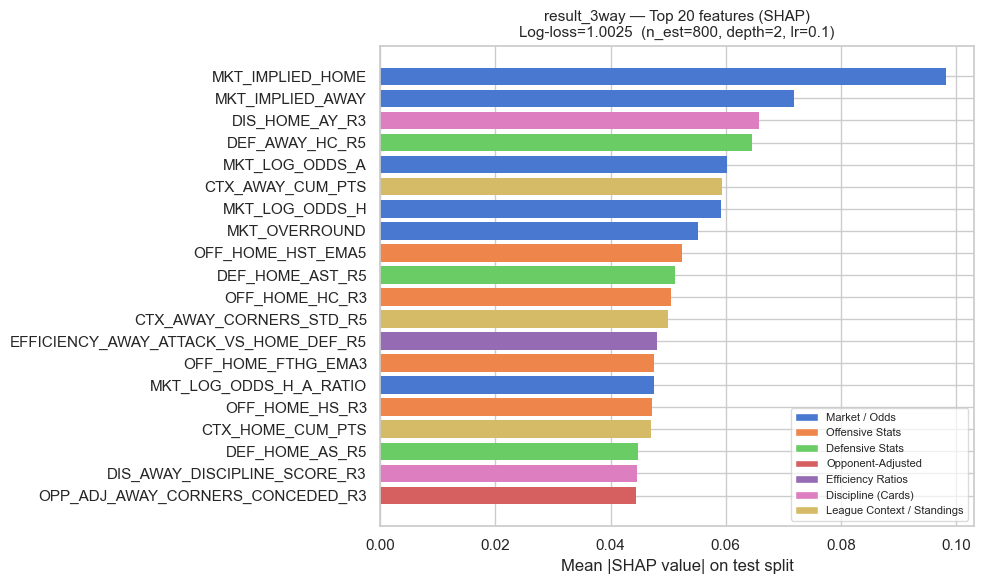

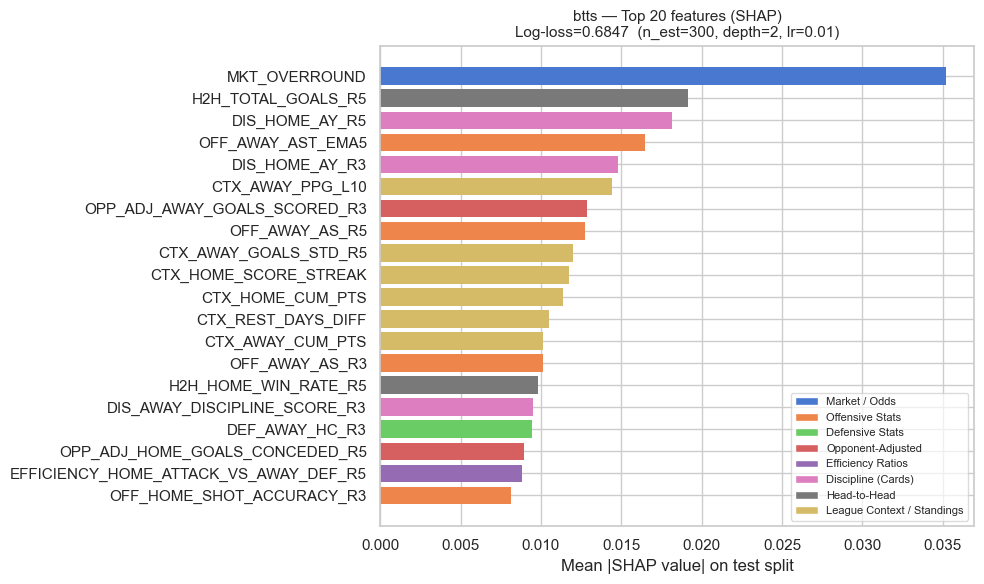

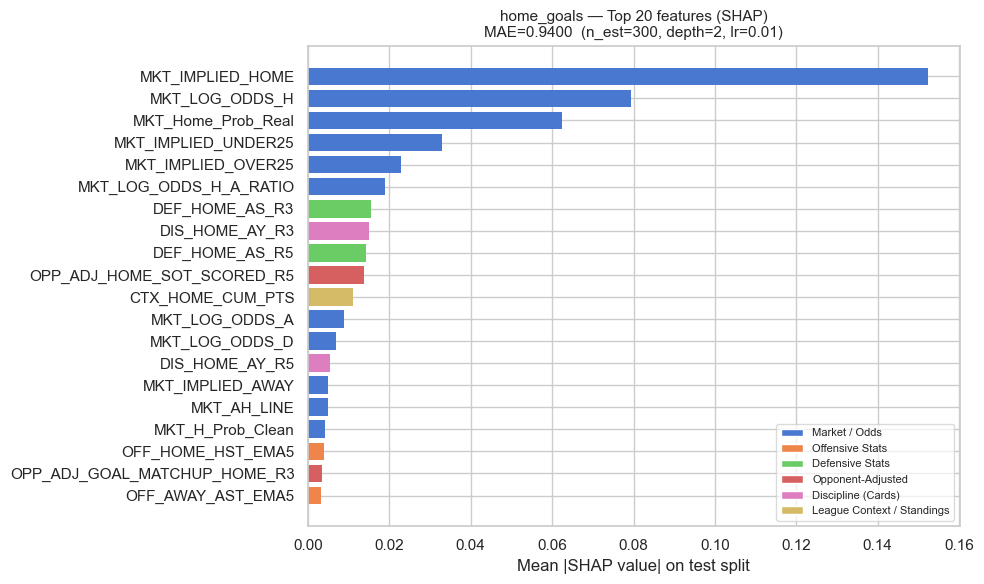

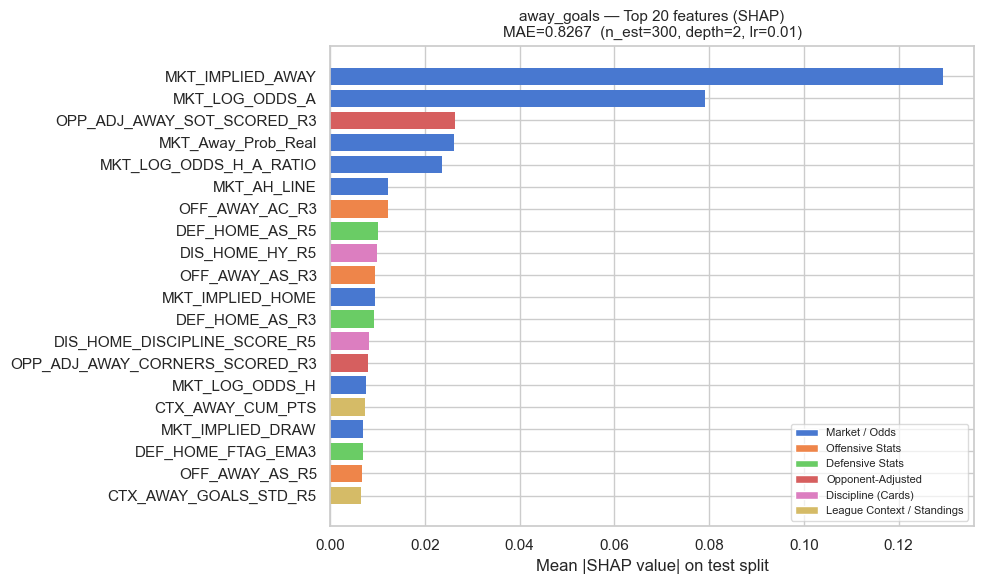

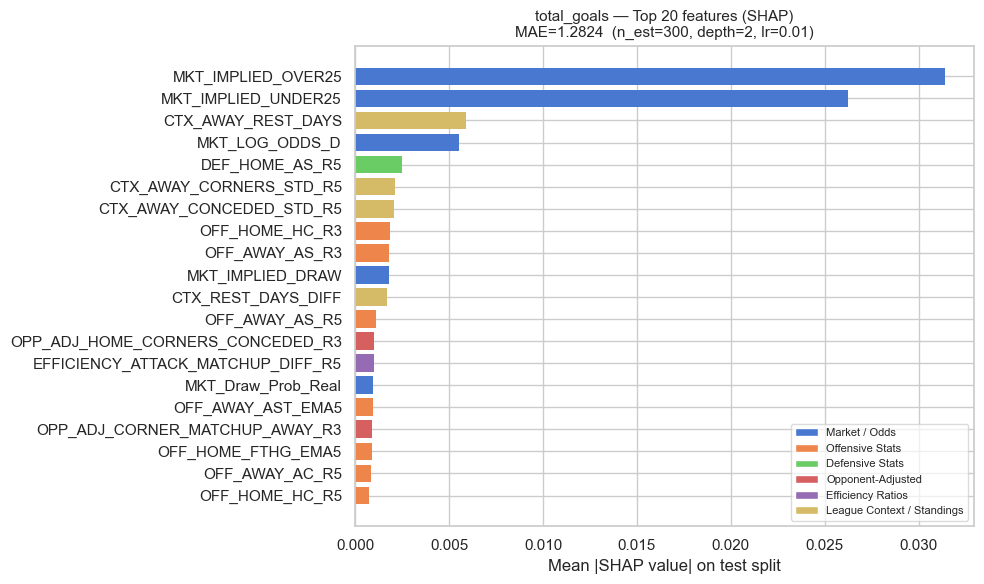

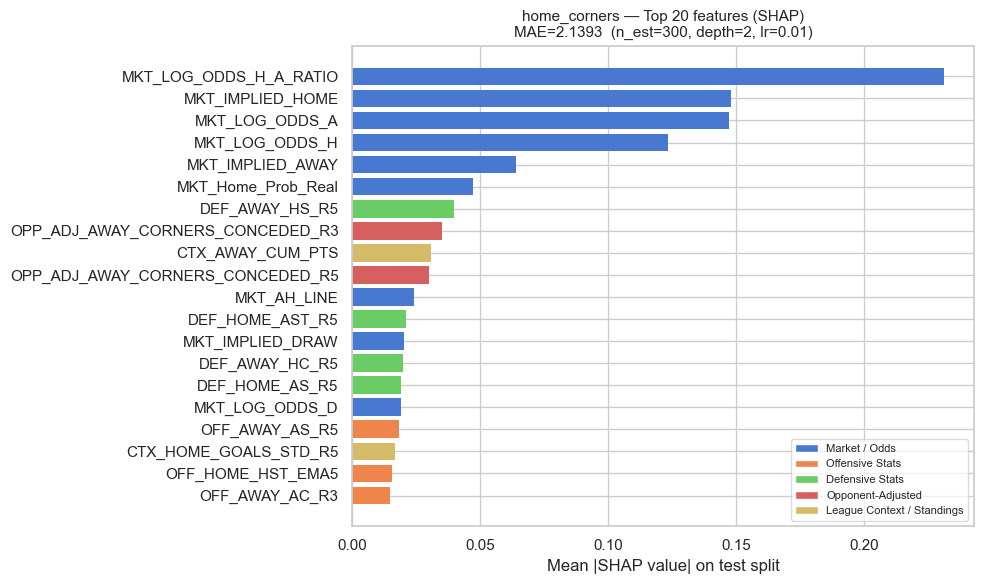

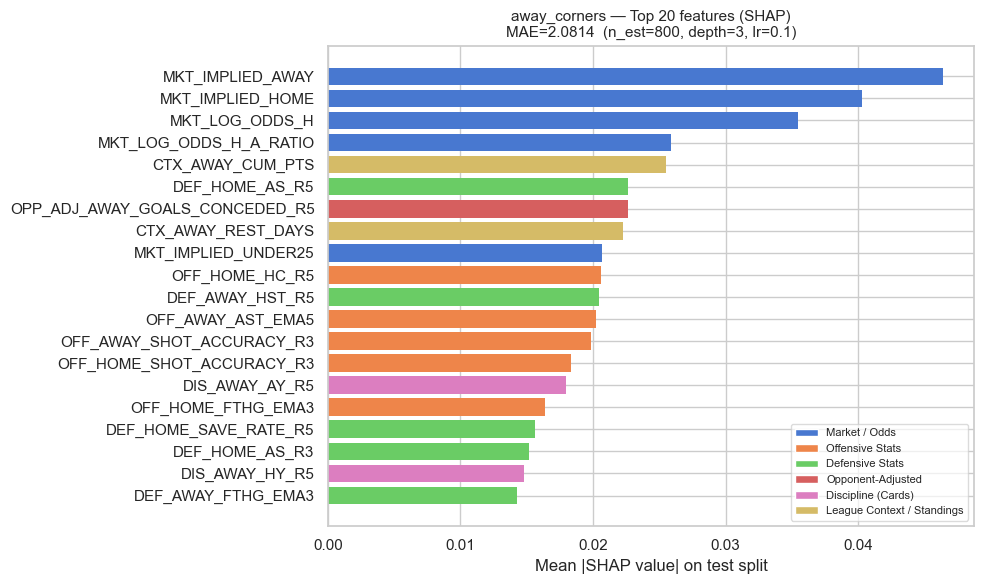

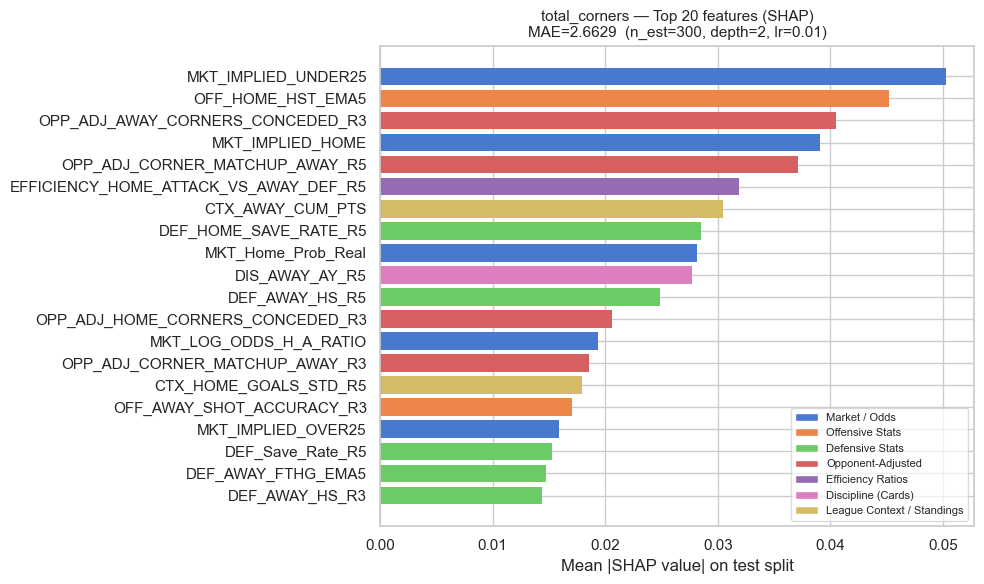

In [70]:
GROUP_COLORS = {
    "Market / Odds":              "#4878d0",
    "Offensive Stats":            "#ee854a",
    "Defensive Stats":            "#6acc65",
    "Opponent-Adjusted":          "#d65f5f",
    "Efficiency Ratios":          "#956cb4",
    "Interaction Terms":          "#8c613c",
    "Discipline (Cards)":         "#dc7ec0",
    "Head-to-Head":               "#797979",
    "League Context / Standings": "#d5bb67",
    "Other":                      "#bbbbbb",
}

TOP_N = 20

for target in TARGETS_ORDER:
    if target not in feature_importance:
        continue
    fi   = feature_importance[target].head(TOP_N)
    info = best_runs[target]
    colors = [GROUP_COLORS.get(g, "#bbbbbb") for g in fi["group"]]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi["feature"][::-1], fi["importance"][::-1],
            color=colors[::-1], edgecolor="none")
    ax.set_xlabel("Mean |SHAP value| on test split")
    ax.set_title(
        f"{target} — Top {TOP_N} features (SHAP)\n"
        f"{info['primary_metric']}={info['primary_value']:.4f}  "
        f"(n_est={info['params'].get('n_estimators','?')}, "
        f"depth={info['params'].get('max_depth','?')}, "
        f"lr={info['params'].get('learning_rate','?')})",
        fontsize=11,
    )
    present_groups = fi["group"].unique()
    legend_patches = [
        plt.Rectangle((0, 0), 1, 1, fc=GROUP_COLORS.get(g, "#bbbbbb"), label=g)
        for g in GROUP_MAP.values() if g in present_groups
    ]
    ax.legend(handles=legend_patches, loc="lower right", fontsize=8, framealpha=0.7)
    plt.tight_layout()
    plt.show()

### 3.1 SHAP Beeswarm Plots

Beeswarm plots show both the **magnitude** (x-axis = SHAP value) and **direction** (positive = pushes prediction higher) of each feature's effect across all test rows. Colour = feature value (red = high, blue = low).

For multiclass (`result_3way`), each class output is shown separately.

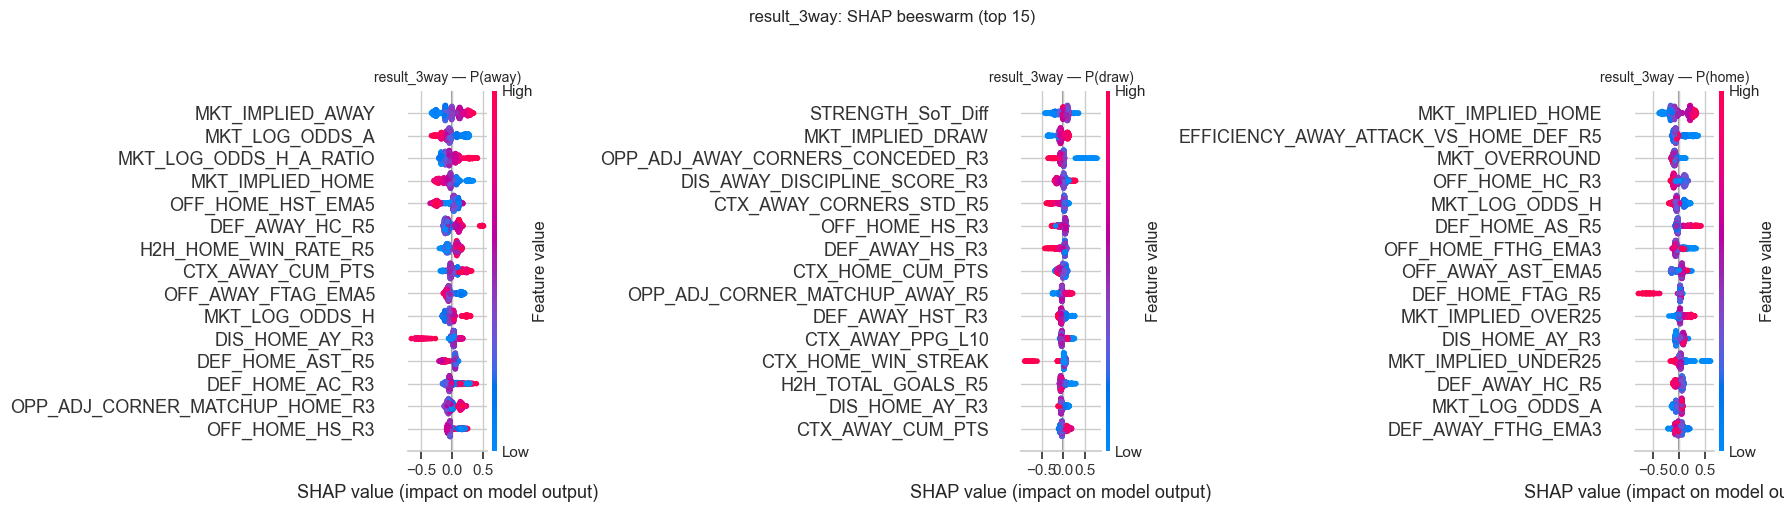

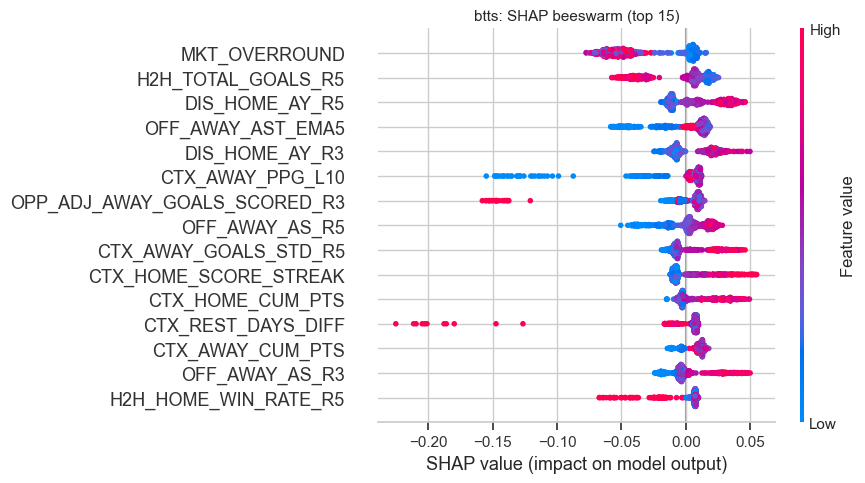

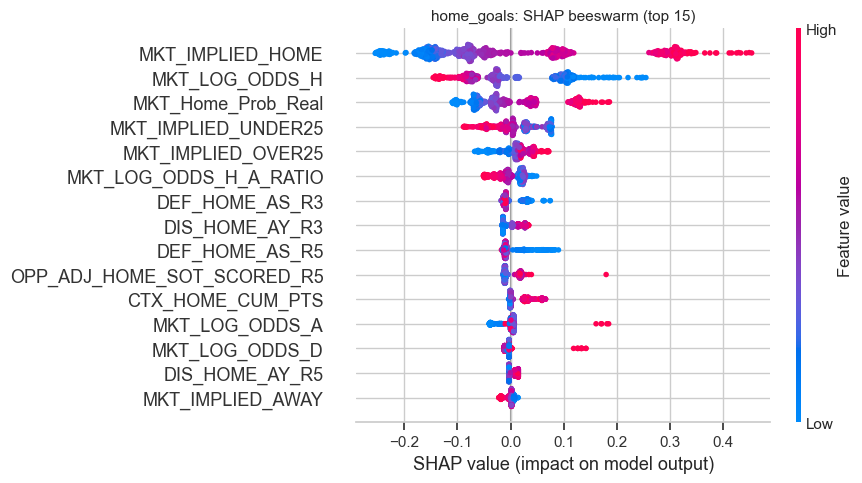

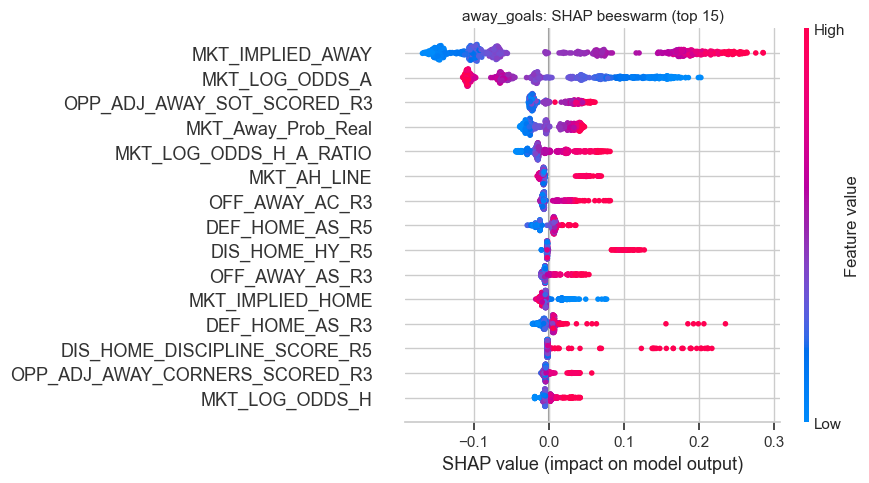

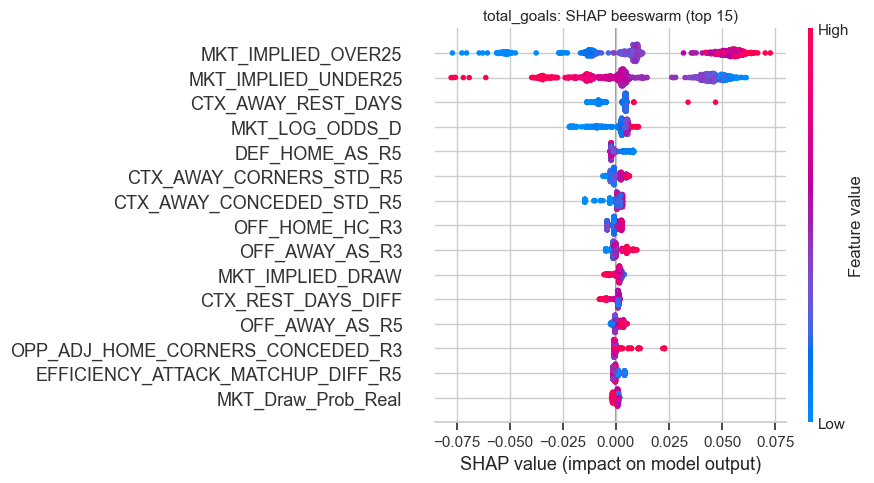

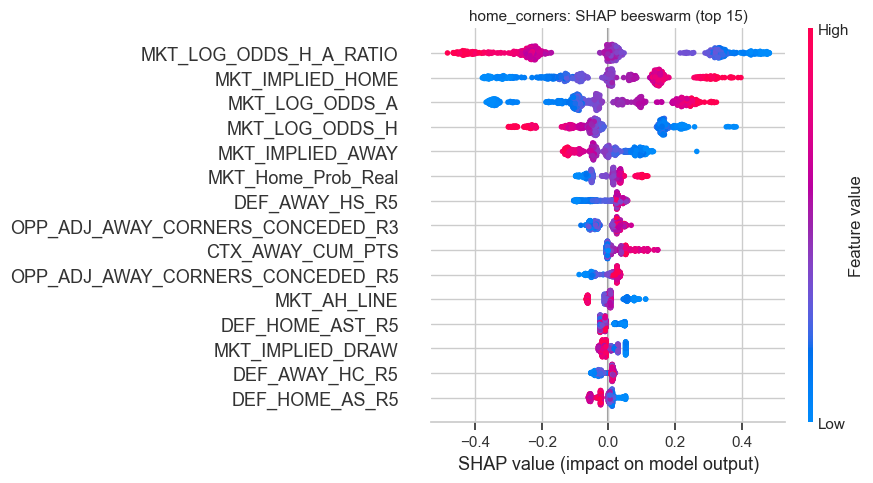

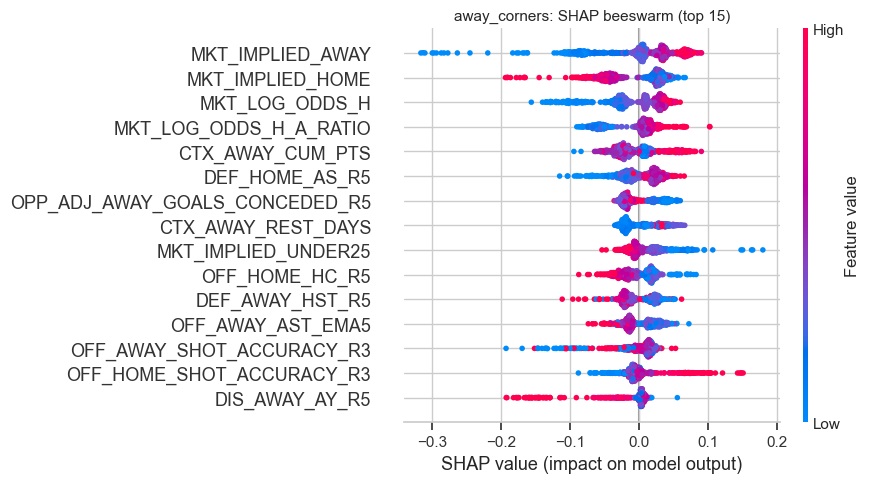

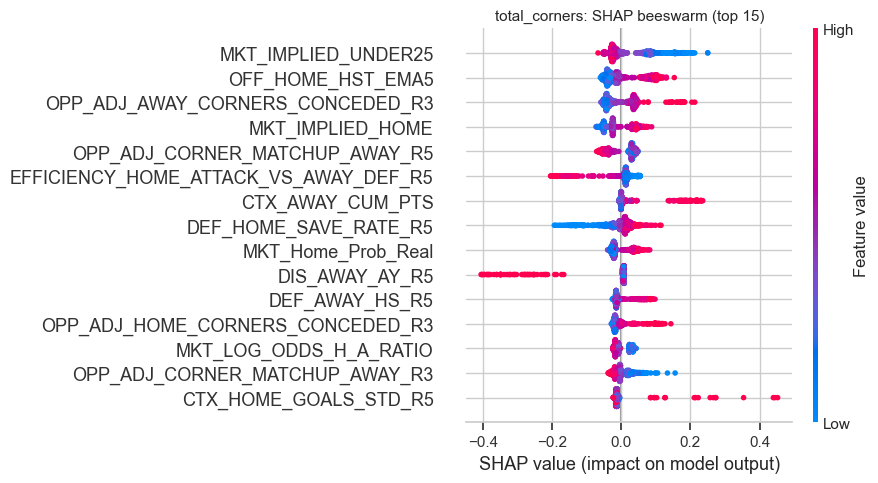

In [71]:
BEESWARM_TOP_N = 15

for target in TARGETS_ORDER:
    if target not in shap_store:
        continue

    store      = shap_store[target]
    sv         = store["shap_values"]
    X_te       = store["X_test"]
    feat_names = store["feature_cols"]
    task       = store["task"]
    le         = store["label_encoder"]

    if task == "multiclass":
        # one beeswarm per class
        classes = le.classes_  # e.g. ['away', 'draw', 'home']
        sv_list = sv if isinstance(sv, list) else [sv[:, :, i] for i in range(sv.shape[2])]
        fig, axes = plt.subplots(1, len(classes), figsize=(6 * len(classes), 5))
        for ax, cls_name, sv_cls in zip(axes, classes, sv_list):
            plt.sca(ax)
            shap.summary_plot(
                sv_cls, X_te,
                feature_names=feat_names,
                max_display=BEESWARM_TOP_N,
                show=False, plot_size=None,
            )
            ax.set_title(f"{target} — P({cls_name})", fontsize=10)
        plt.suptitle(f"{target}: SHAP beeswarm (top {BEESWARM_TOP_N})", fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()
    else:
        fig, ax = plt.subplots(figsize=(9, 5))
        plt.sca(ax)
        shap.summary_plot(
            sv, X_te,
            feature_names=feat_names,
            max_display=BEESWARM_TOP_N,
            show=False, plot_size=None,
        )
        ax.set_title(f"{target}: SHAP beeswarm (top {BEESWARM_TOP_N})", fontsize=11)
        plt.tight_layout()
        plt.show()

## 3.2 Sample-Level SHAP — Best to Worst Predictions

For each target, 5 test samples are selected spanning the full accuracy spectrum:
- **Sample 1** — best prediction (lowest error)
- **Samples 2–4** — 25th, 50th, 75th percentile of error
- **Sample 5** — worst prediction (highest error)

Each panel shows the **top 10 SHAP values** for that sample.
- **Red bars** push the prediction higher; **blue bars** push it lower.
- The feature value for that specific match is shown on the right.

**Error metric per task**
- Regressors: absolute error `|predicted − actual|`
- Classifiers: per-sample log-loss `−log(P(true class))` — higher = model was more wrong / more confident in the wrong direction

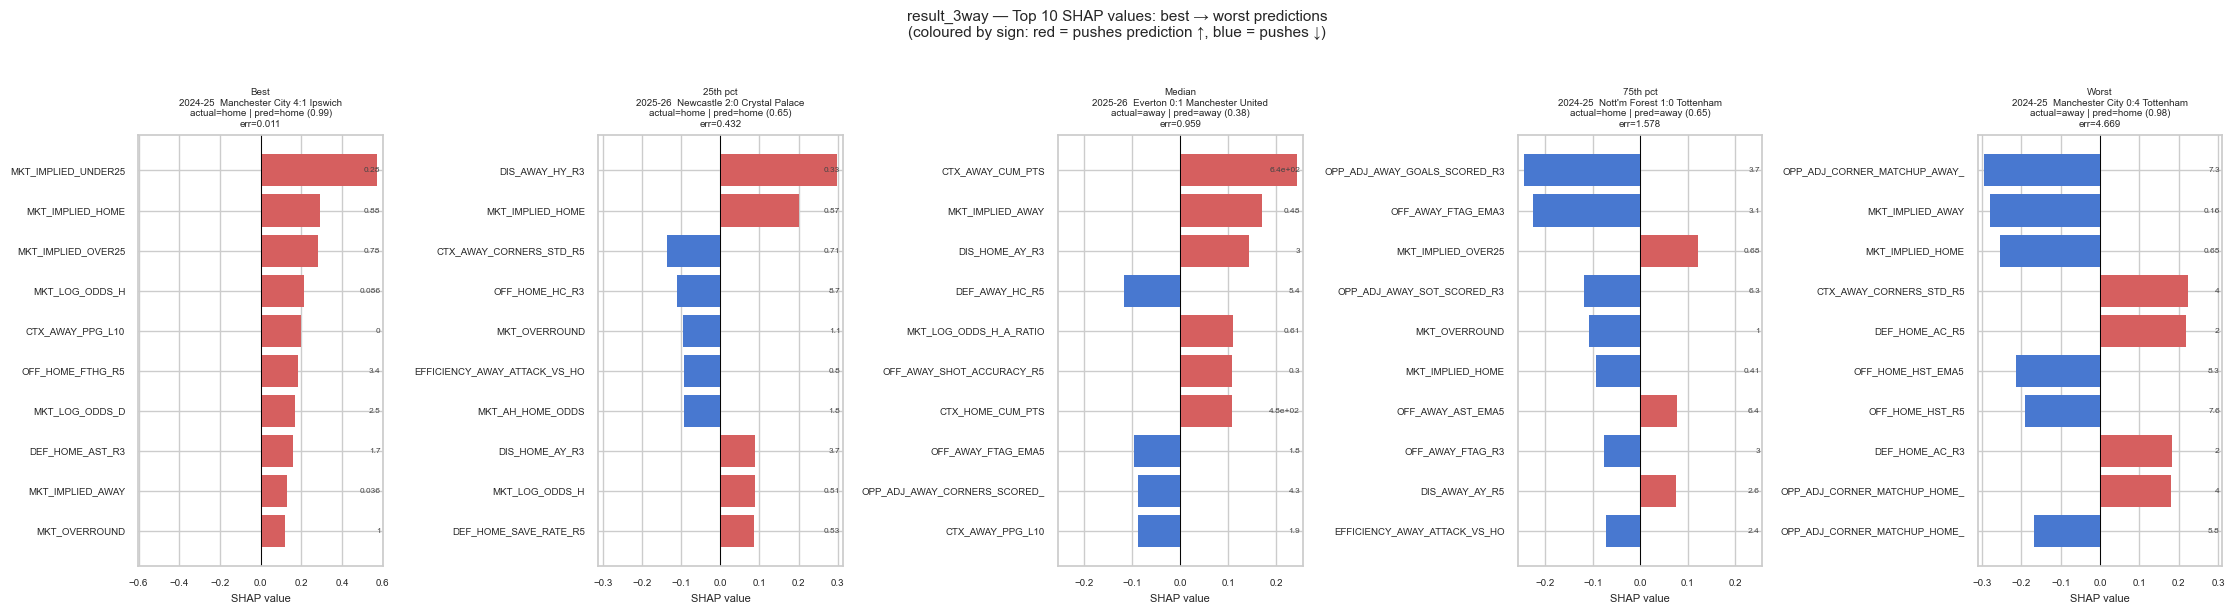

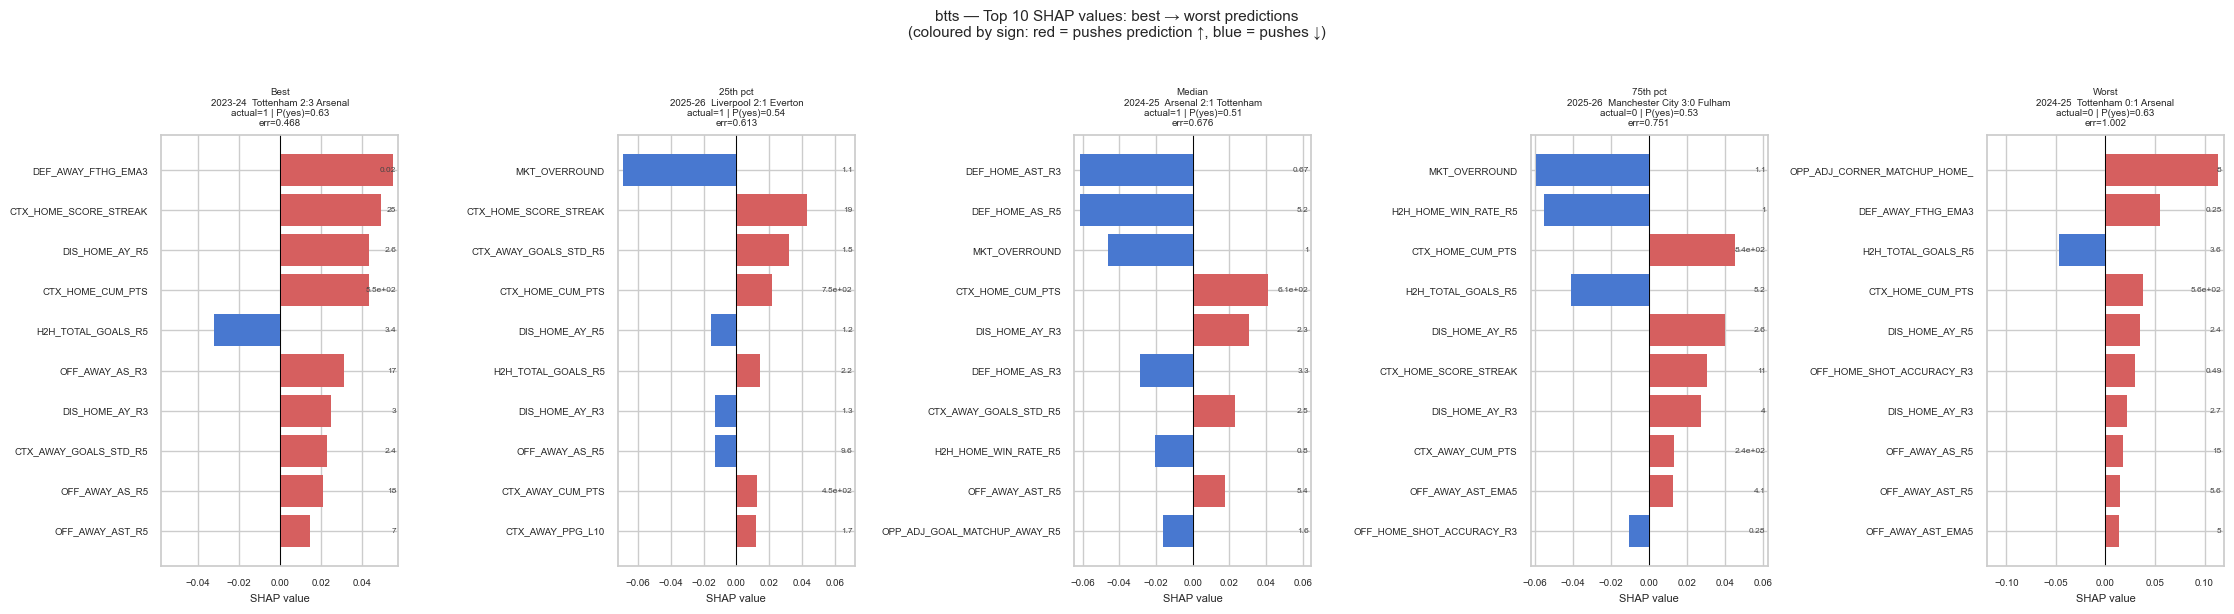

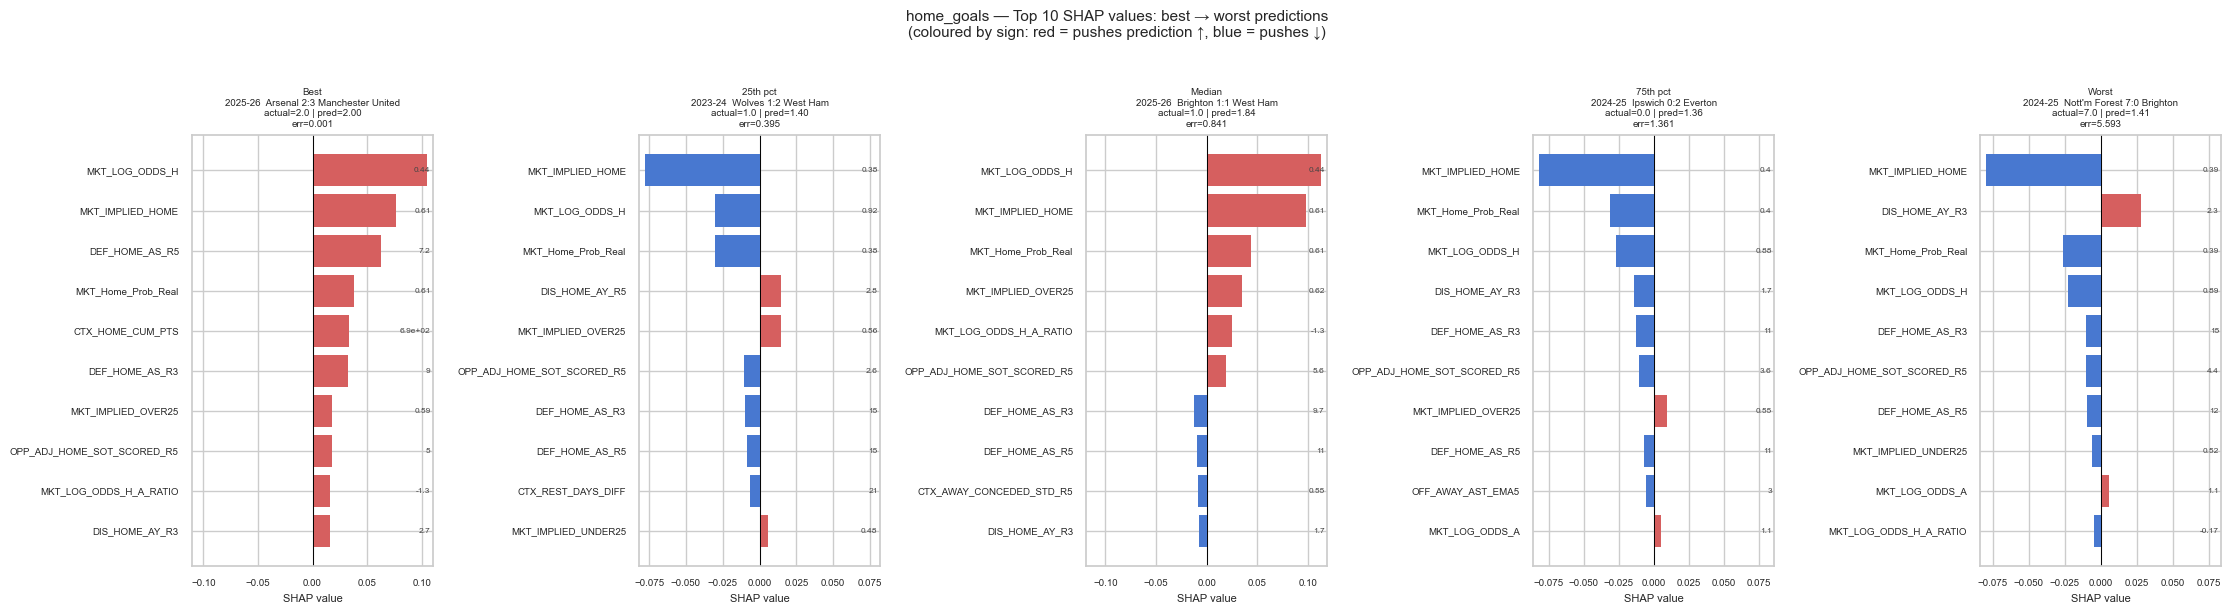

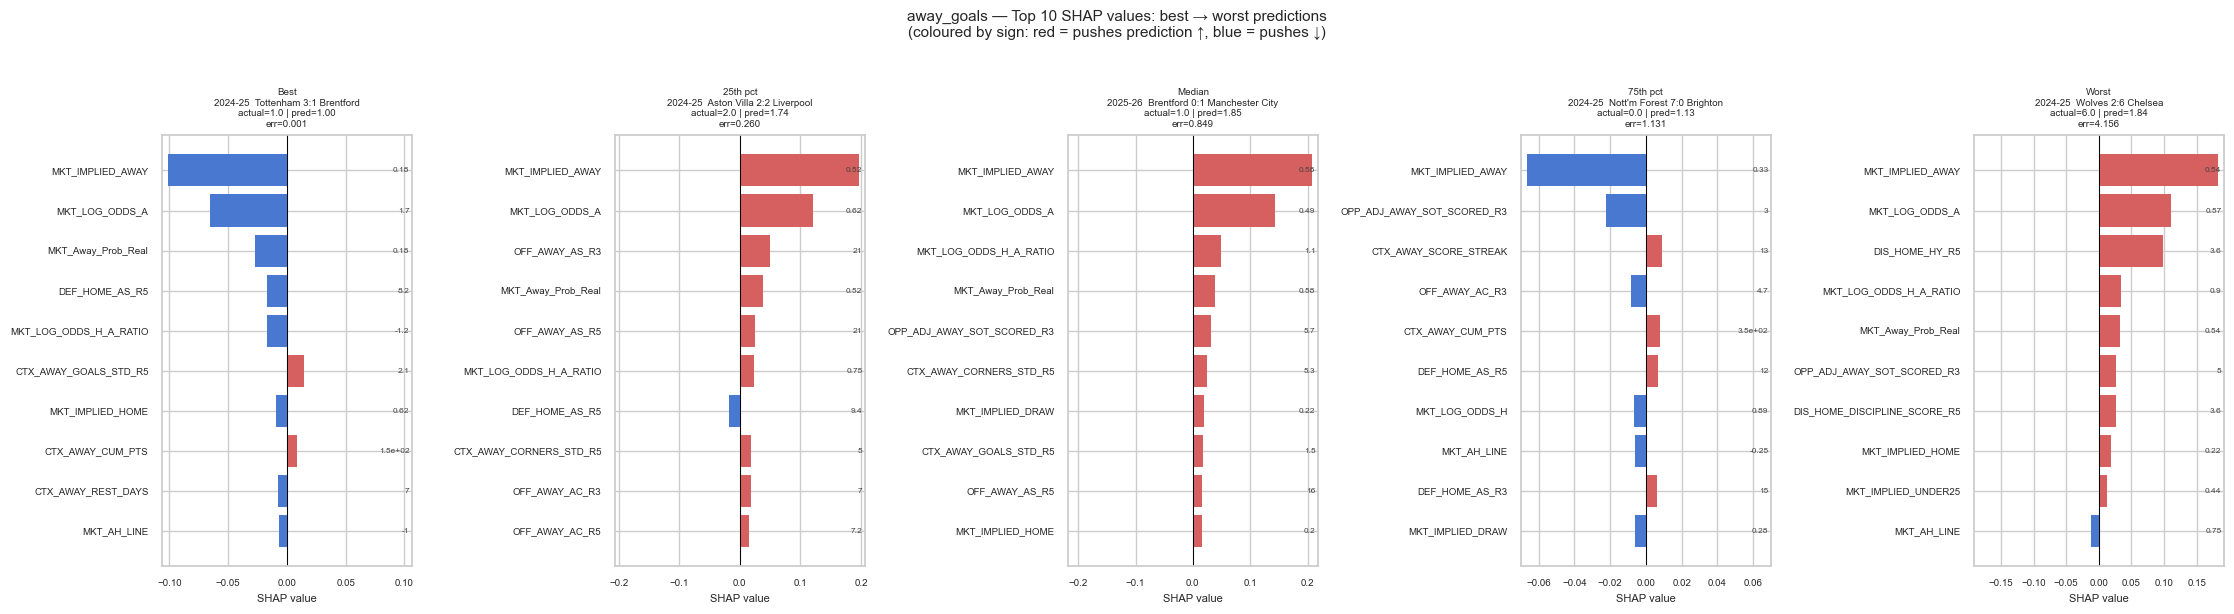

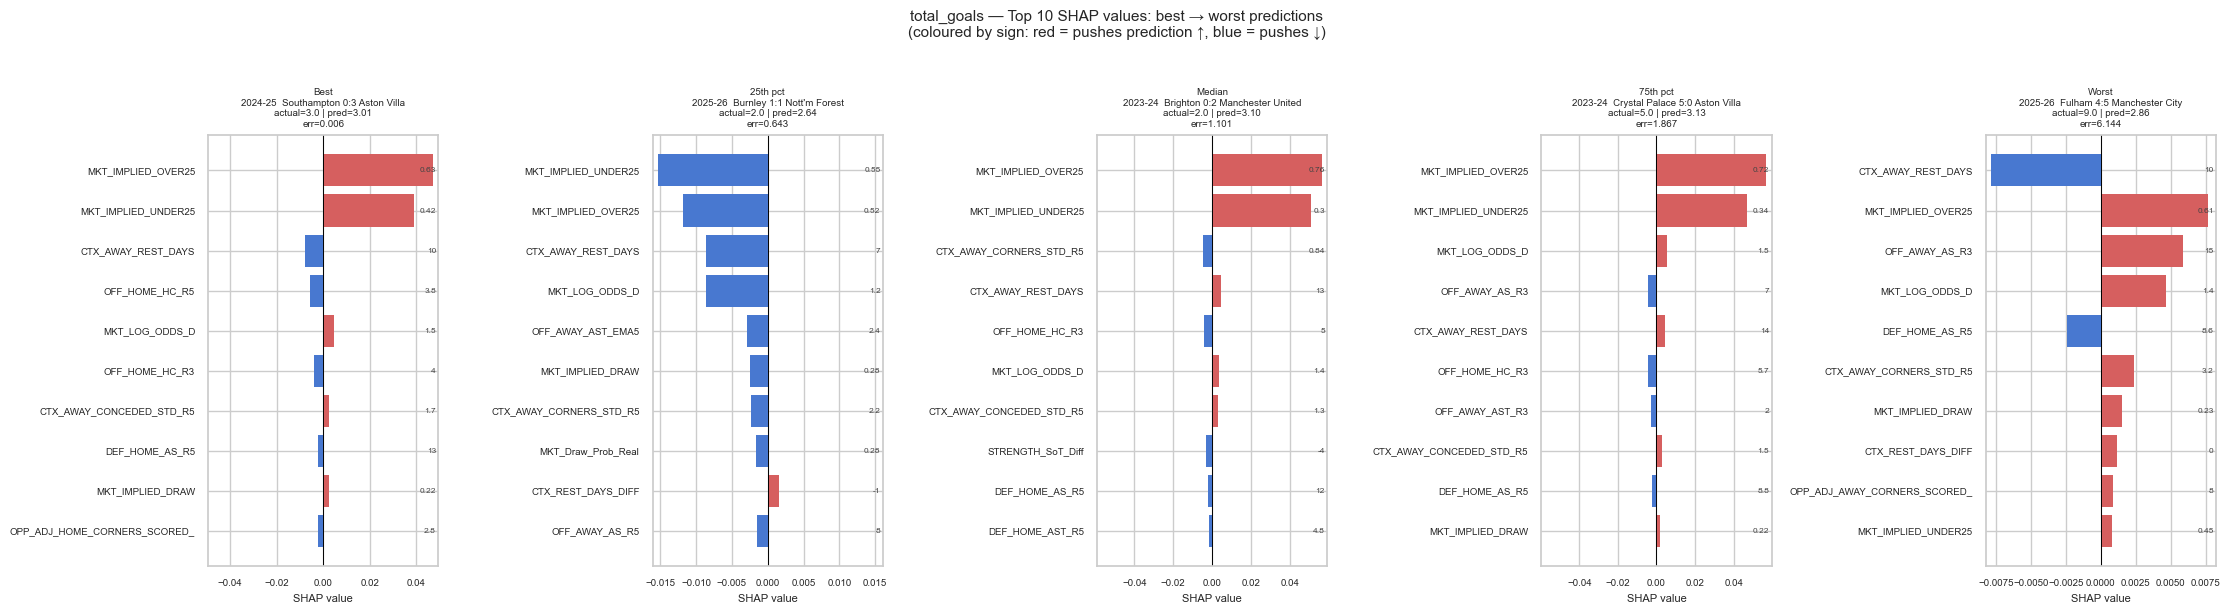

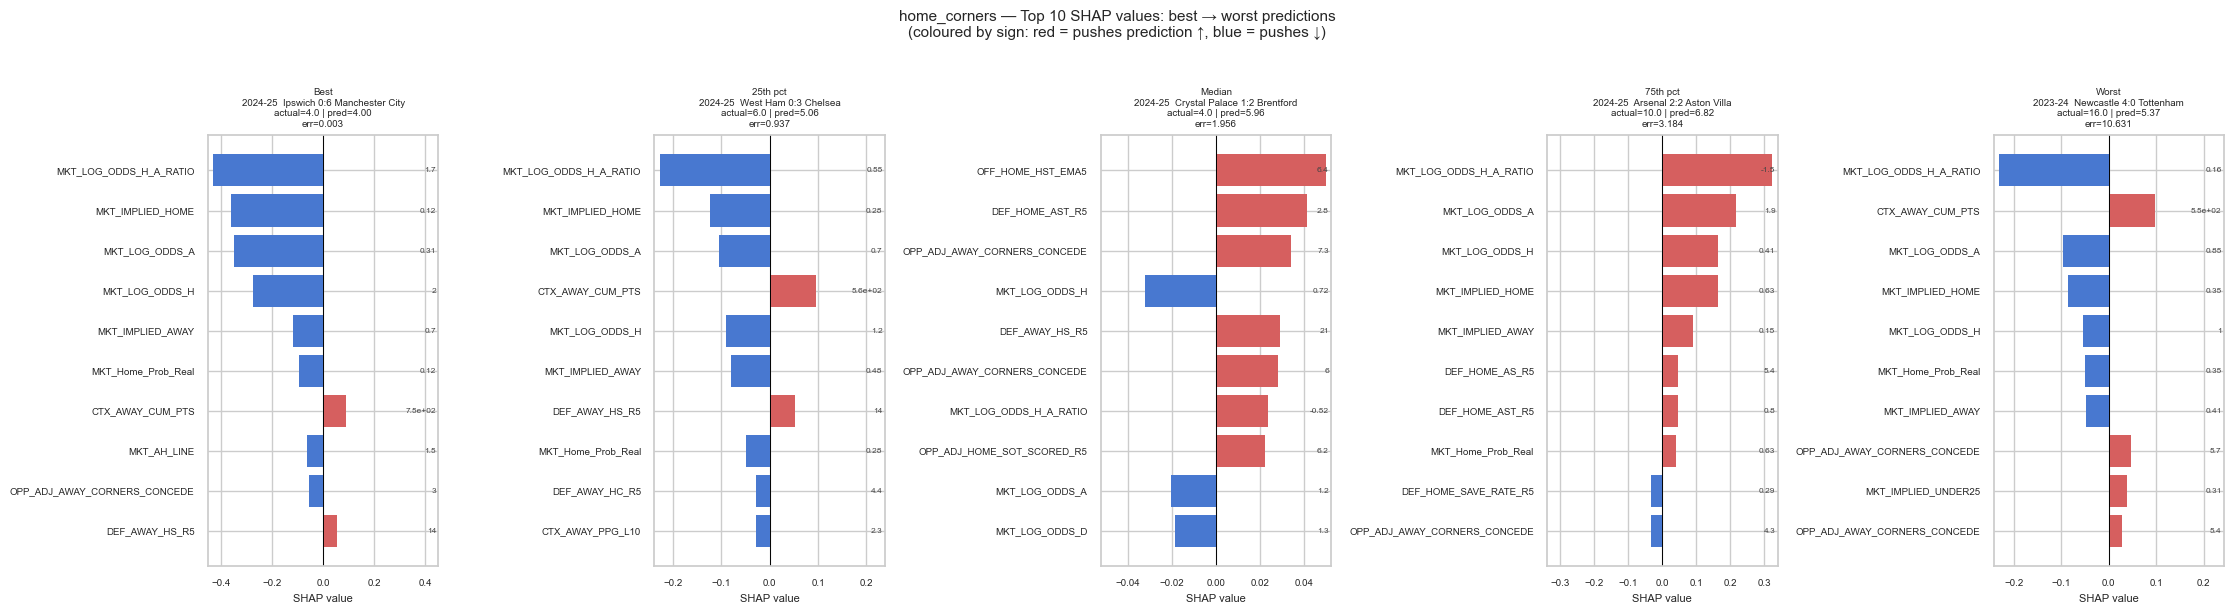

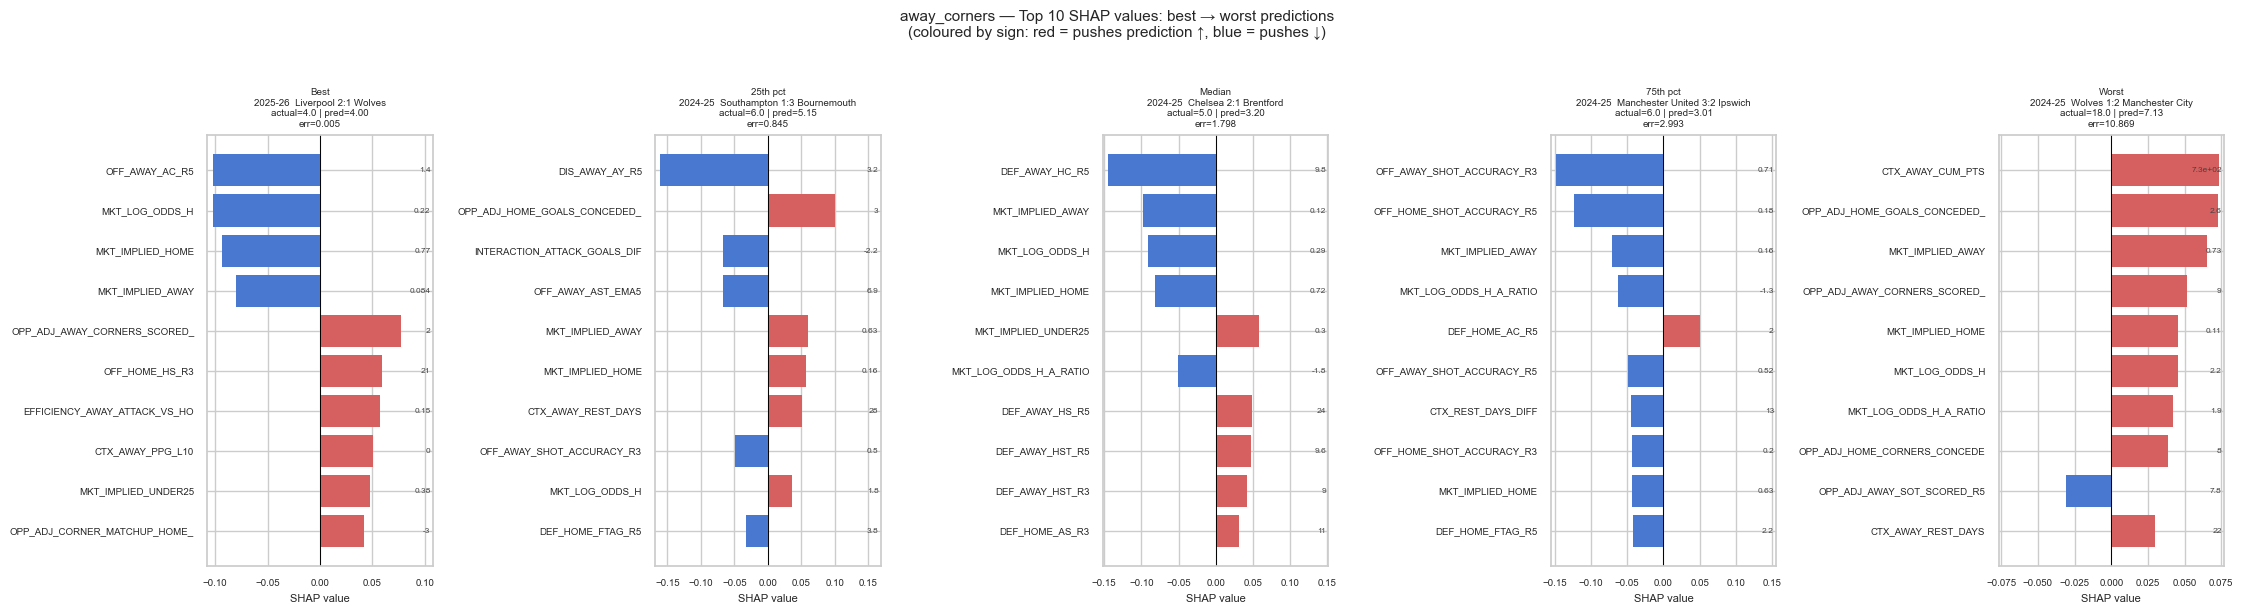

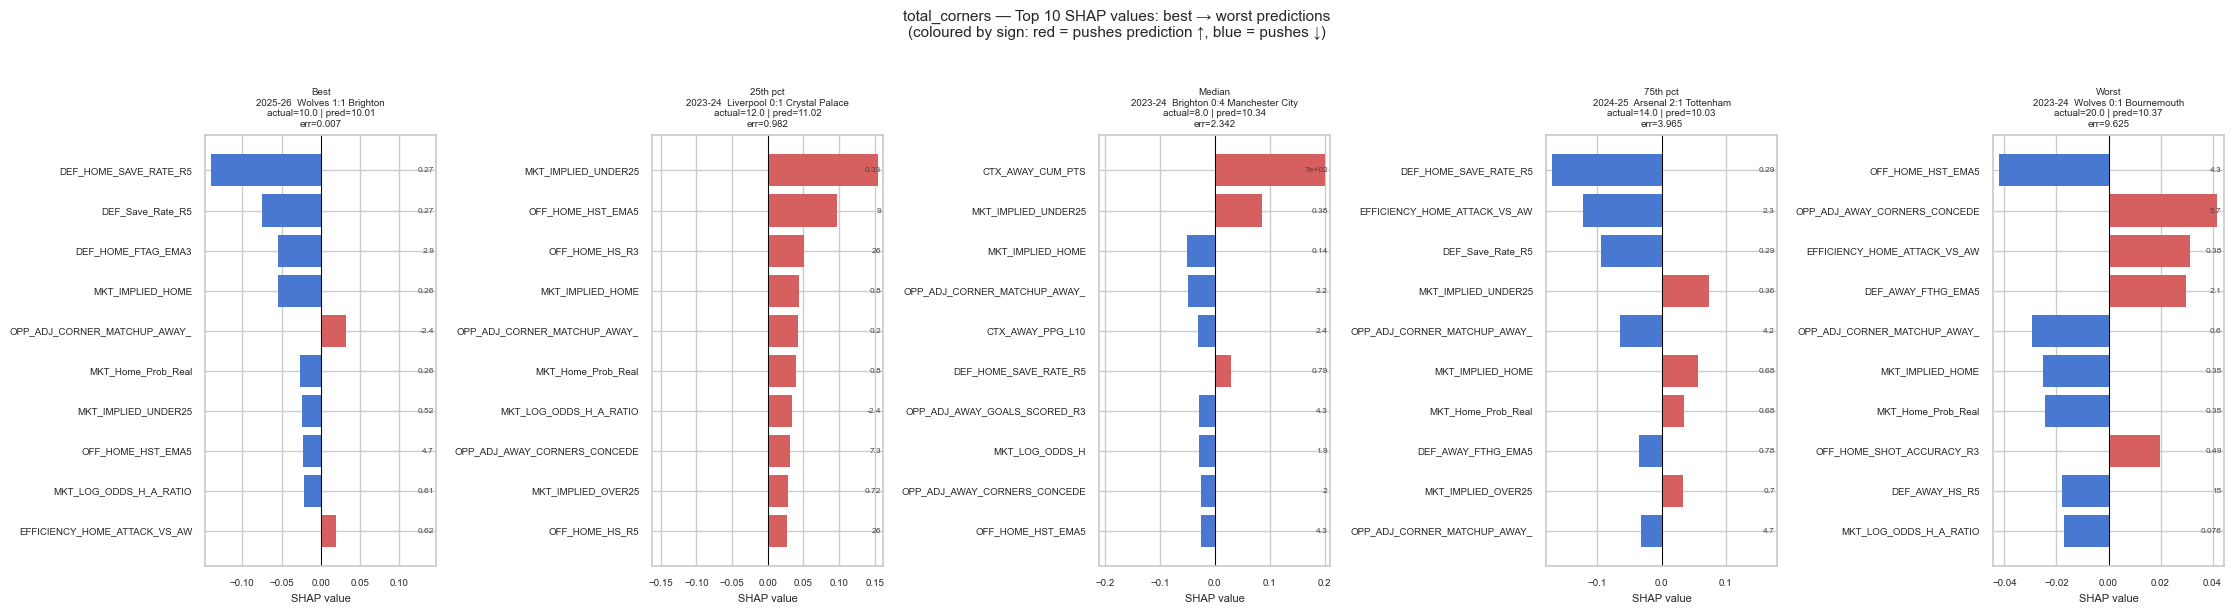

In [72]:
EPS      = 1e-9
TOP_SHAP = 10
N_SAMPLES = 5


def _match_title(store: dict, row_idx: int) -> str:
    """Return season + scoreline string, e.g. '2016-17 Arsenal 3:1 Chelsea'."""
    meta = store["match_meta"].iloc[row_idx]
    dt   = pd.Timestamp(meta["date"])
    yr   = dt.year
    start = yr if dt.month >= 8 else yr - 1
    season = f"{start}-{str(start + 1)[-2:]}"
    home = meta["home_team"]
    away = meta["away_team"]
    try:
        score = f"{int(meta['fthg'])}:{int(meta['ftag'])}"
    except (ValueError, TypeError):
        score = "?:?"
    return f"{season}  {home} {score} {away}"

def _per_sample_error(store: dict) -> np.ndarray:
    """Return per-sample error array (length = n_test), lower = better."""
    model     = store["model"]
    X_te      = store["X_test"]
    y_orig    = store["y_test_orig"].values
    le        = store["label_encoder"]
    task      = store["task"]

    if task == "regression":
        preds = model.predict(X_te)
        return np.abs(preds - y_orig.astype(float))

    proba = model.predict_proba(X_te)   # (n, n_classes)

    if task == "binary":
        # y_orig is 0/1; grab probability of true class
        p_true = np.where(y_orig == 1, proba[:, 1], proba[:, 0])
    else:
        # multiclass: y_orig is string label; le maps to int
        y_enc  = le.transform(y_orig)
        p_true = proba[np.arange(len(y_enc)), y_enc]

    return -np.log(np.clip(p_true, EPS, 1.0))   # per-sample log-loss


def _shap_for_sample(store: dict, row_idx: int):
    """
    Return (shap_array_1d, base_value) for a single test row.
    For multiclass, explains the TRUE class; for binary, explains class-1.
    """
    sv   = store["shap_values"]
    le   = store["label_encoder"]
    task = store["task"]
    y_enc = store["y_test_enc"]

    if task == "regression" or task == "binary":
        if sv.ndim == 3:
            sv = sv[:, :, -1]   # binary: class-1 slice
        return sv[row_idx]

    # multiclass: pick slice for the true class
    true_cls = int(y_enc[row_idx])
    if isinstance(sv, list):
        return sv[true_cls][row_idx]
    return sv[row_idx, :, true_cls]


def _prediction_label(store: dict, row_idx: int) -> str:
    """Human-readable prediction for the sample."""
    model  = store["model"]
    X_te   = store["X_test"]
    le     = store["label_encoder"]
    task   = store["task"]

    if task == "regression":
        pred = float(model.predict(X_te.iloc[[row_idx]])[0])
        return f"pred={pred:.2f}"

    proba = model.predict_proba(X_te.iloc[[row_idx]])[0]
    if task == "binary":
        return f"P(yes)={proba[1]:.2f}"
    pred_cls = le.classes_[np.argmax(proba)]
    p_pred   = proba.max()
    return f"pred={pred_cls} ({p_pred:.2f})"


def _actual_label(store: dict, row_idx: int) -> str:
    """Human-readable actual label for the sample."""
    y = store["y_test_orig"].values[row_idx]
    task = store["task"]
    if task == "regression":
        return f"actual={float(y):.1f}"
    return f"actual={y}"


for target in TARGETS_ORDER:
    if target not in shap_store:
        continue

    store  = shap_store[target]
    errors = _per_sample_error(store)
    n_test = len(errors)

    # pick 5 quantile positions across the error distribution
    quantiles   = [0.0, 0.25, 0.50, 0.75, 1.0]
    sorted_idx  = np.argsort(errors)
    sample_positions = [int(q * (n_test - 1)) for q in quantiles]
    sample_rows = [sorted_idx[pos] for pos in sample_positions]
    labels      = ["Best", "25th pct", "Median", "75th pct", "Worst"]

    fig, axes = plt.subplots(1, N_SAMPLES, figsize=(N_SAMPLES * 4.5, 6),
                             sharey=False)
    fig.suptitle(
        f"{target} — Top {TOP_SHAP} SHAP values: best → worst predictions\n"
        f"(coloured by sign: red = pushes prediction ↑, blue = pushes ↓)",
        fontsize=11, y=1.02,
    )

    for ax, row_idx, rank_label in zip(axes, sample_rows, labels):
        sv_row   = _shap_for_sample(store, row_idx)          # (n_features,)
        feat_names = store["feature_cols"]

        top10_pos = np.argsort(np.abs(sv_row))[-TOP_SHAP:]   # ascending → last = biggest
        top10_pos = top10_pos[::-1]                           # sort descending

        vals  = sv_row[top10_pos]
        names = [feat_names[i] for i in top10_pos]
        fvals = store["X_test"].iloc[row_idx].values[top10_pos]

        colors = ["#d65f5f" if v > 0 else "#4878d0" for v in vals]

        # plot horizontally (largest at top → reversed for barh)
        ax.barh(range(TOP_SHAP), vals[::-1], color=colors[::-1], edgecolor="none")
        ax.set_yticks(range(TOP_SHAP))
        ax.set_yticklabels(
            [n[:28] for n in names[::-1]],   # truncate long names
            fontsize=7,
        )
        ax.axvline(0, color="black", lw=0.7, ls="-")

        # annotate feature value on the right of each bar
        x_max = max(abs(vals).max() * 1.05, 1e-6)
        for yi, (v, fv) in enumerate(zip(vals[::-1], fvals[::-1])):
            ax.text(
                x_max * 0.98, yi,
                f"{fv:.2g}",
                va="center", ha="right", fontsize=6, color="#444444",
            )

        ax.set_xlim(-x_max, x_max)
        ax.set_xlabel("SHAP value", fontsize=8)
        err_val    = errors[row_idx]
        pred_str   = _prediction_label(store, row_idx)
        actual_str = _actual_label(store, row_idx)
        match_str  = _match_title(store, row_idx)
        ax.set_title(
            f"{rank_label}\n{match_str}\n{actual_str} | {pred_str}\nerr={err_val:.3f}",
            fontsize=7,
        )
        ax.tick_params(axis="x", labelsize=7)

    plt.tight_layout()
    plt.show()

## 4. Feature Group Contribution by Target

Aggregated importance per feature group, normalised to 100% within each target. Shows which *families* of features drive each model.

In [73]:
# ── build group-level importance matrix ───────────────────────────────────
group_rows = []
for target in TARGETS_ORDER:
    if target not in feature_importance:
        continue
    fi = feature_importance[target].copy()
    total = fi["importance"].sum()
    by_group = (
        fi.groupby("group")["importance"]
        .sum()
        .div(total)
        .mul(100)
        .rename(target)
    )
    group_rows.append(by_group)

group_pct = pd.concat(group_rows, axis=1).fillna(0).T

# reorder columns by total importance
col_order = group_pct.sum().sort_values(ascending=False).index.tolist()
group_pct = group_pct[col_order]

print("Feature group % contribution per target (normalised within target):")
display(group_pct.round(1))

Feature group % contribution per target (normalised within target):


group,Market / Odds,Opponent-Adjusted,Offensive Stats,Defensive Stats,League Context / Standings,Discipline (Cards),Efficiency Ratios,Head-to-Head,Interaction Terms,Other
result_3way,16.200001,16.799999,19.200001,17.299999,13.3,9.2,2.7,2.5,1.7,1.3
btts,15.400000,16.100000,17.200001,9.300000,18.4,13.9,2.4,6.0,0.8,0.5
home_goals,71.800003,6.500000,3.300000,7.200000,4.5,5.3,0.9,0.0,0.4,0.1
away_goals,59.299999,11.000000,9.900000,7.200000,6.8,4.1,0.4,0.7,0.4,0.2
total_goals,62.099998,5.200000,10.700000,4.000000,14.0,1.9,1.2,0.0,0.7,0.2
home_corners,64.800003,8.200000,6.300000,12.300000,5.9,0.6,0.3,0.4,1.0,0.3
away_corners,18.299999,18.700001,19.400000,16.900000,12.5,7.4,2.0,2.0,1.4,1.4
total_corners,22.900000,20.200001,15.600000,16.700001,11.6,5.3,4.6,1.2,1.1,0.8


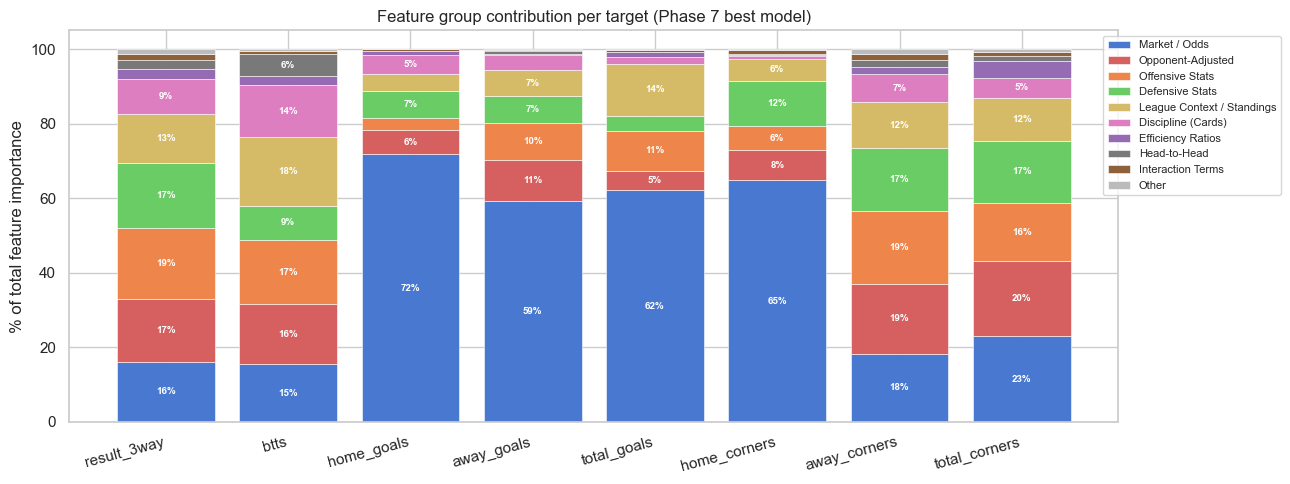

In [74]:
# ── stacked bar: group contribution ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

bottom = np.zeros(len(group_pct))
x = np.arange(len(group_pct))

for col in group_pct.columns:
    vals = group_pct[col].values
    color = GROUP_COLORS.get(col, "#bbbbbb")
    bars = ax.bar(x, vals, bottom=bottom, color=color, label=col, edgecolor="white", linewidth=0.4)
    # label bars >= 5%
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 5:
            ax.text(xi, b + v / 2, f"{v:.0f}%", ha="center", va="center", fontsize=7, color="white", fontweight="bold")
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(group_pct.index, rotation=15, ha="right")
ax.set_ylabel("% of total feature importance")
ax.set_title("Feature group contribution per target (Phase 7 best model)")
ax.set_ylim(0, 105)
ax.legend(loc="upper right", bbox_to_anchor=(1.16, 1), fontsize=8)

plt.tight_layout()
plt.show()

## 5. Cross-Target Importance Heatmap

Ranks each feature (1 = most important, N = least) within each target's model. Uses a union of the top-30 features across all targets.

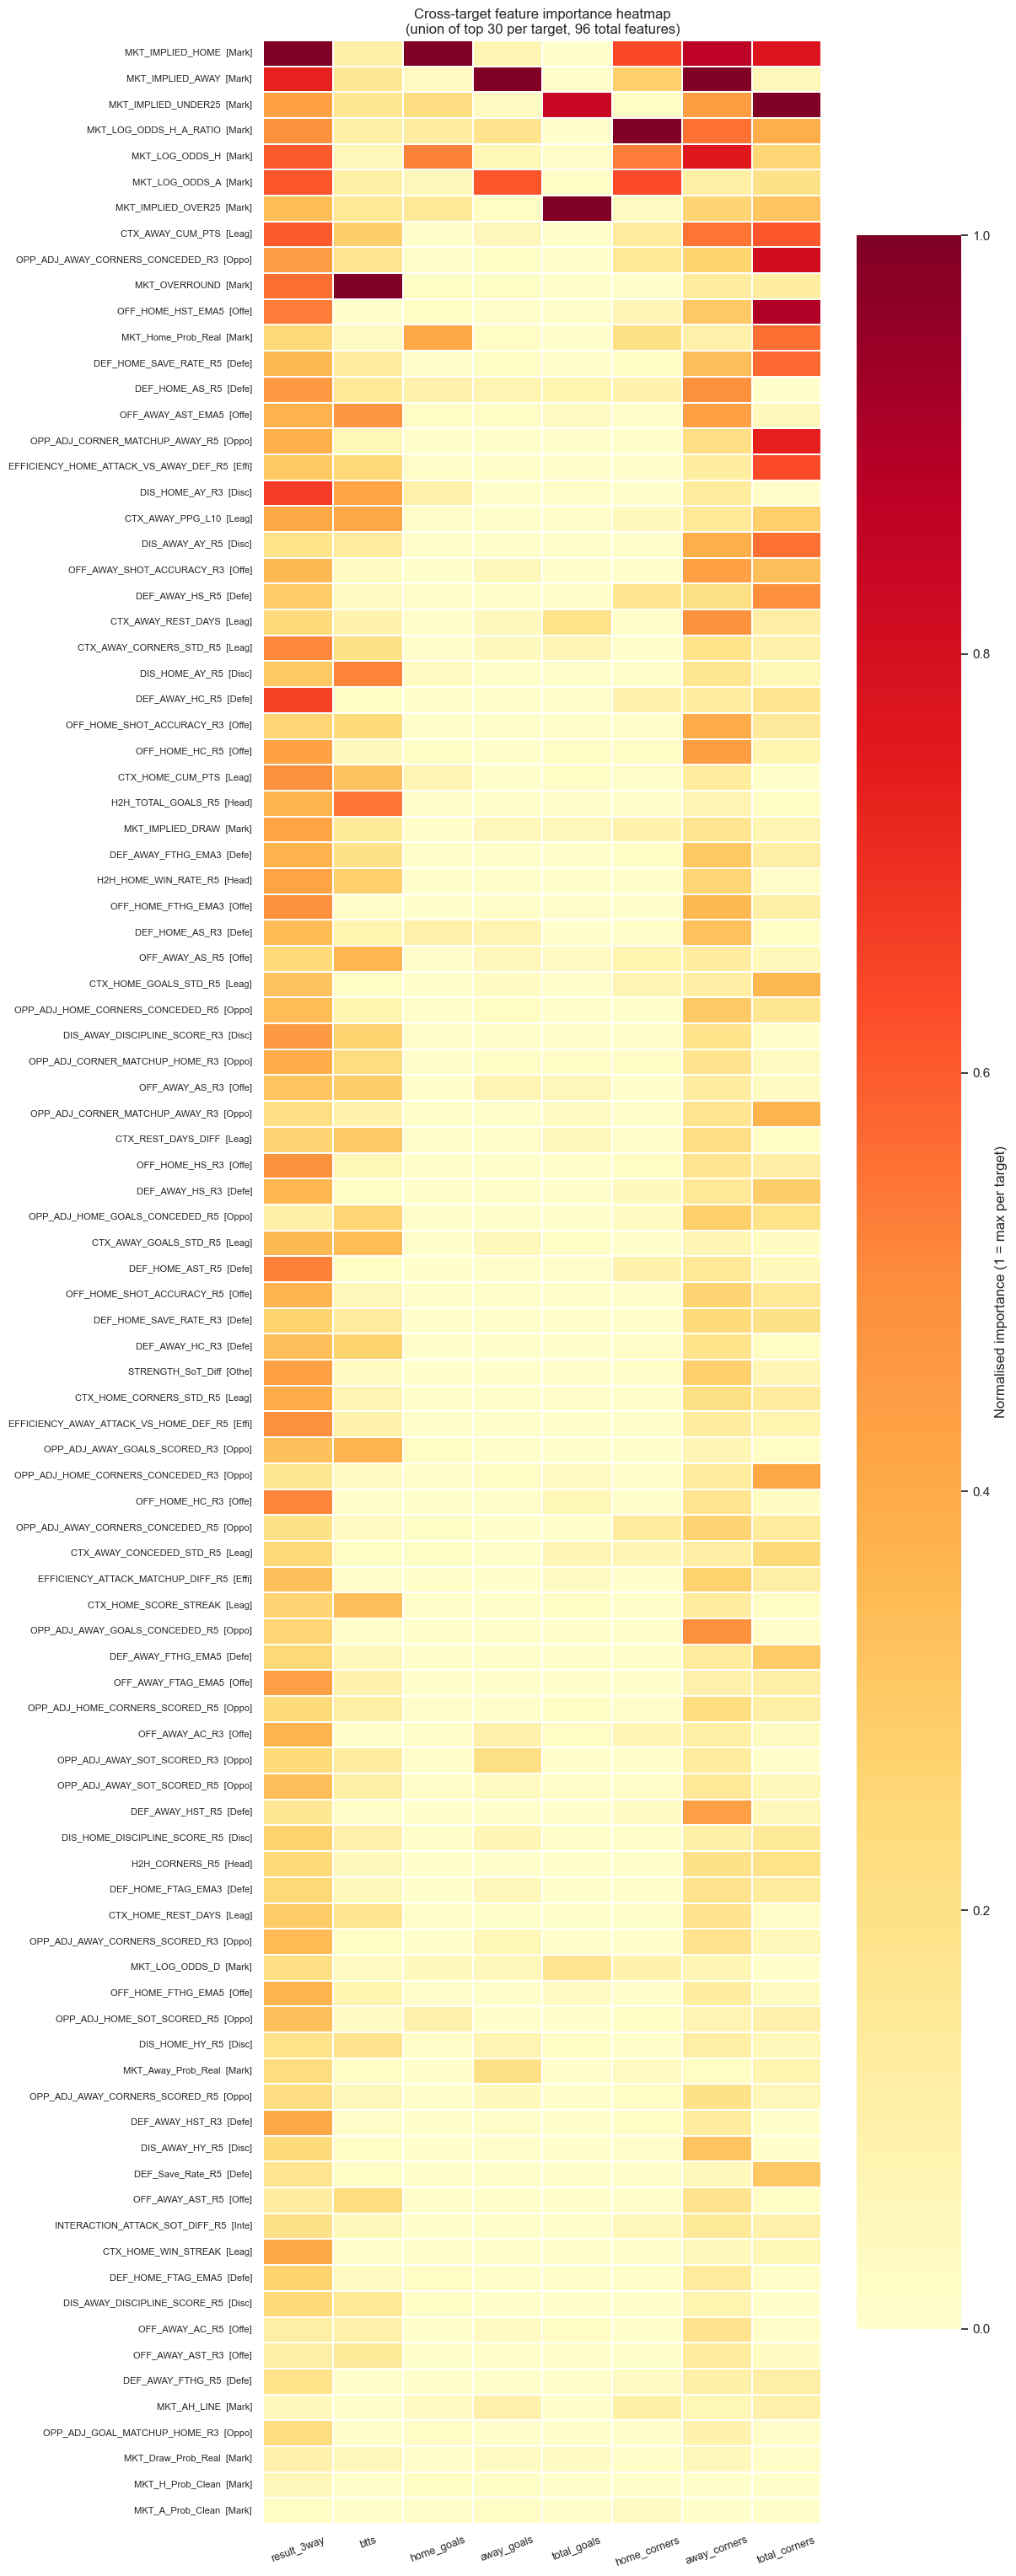

In [75]:
TOP_UNION = 30  # features per target to include in union

# build union of top-N features across all targets
union_features: set[str] = set()
for target in TARGETS_ORDER:
    if target in feature_importance:
        union_features.update(feature_importance[target].head(TOP_UNION)["feature"].tolist())

# build importance matrix (raw importance, not rank) for the union
imp_matrix = pd.DataFrame(index=sorted(union_features))
for target in TARGETS_ORDER:
    if target not in feature_importance:
        continue
    fi = feature_importance[target].set_index("feature")["importance"]
    imp_matrix[target] = fi.reindex(imp_matrix.index).fillna(0)

# normalise each column (target) to [0, 1]
imp_norm = imp_matrix.div(imp_matrix.max(axis=0)).fillna(0)

# sort rows by mean normalised importance
imp_norm = imp_norm.loc[imp_norm.mean(axis=1).sort_values(ascending=False).index]

# add group label
row_labels = [
    f"{feat}  [{_feature_group(feat)[:4]}]"
    for feat in imp_norm.index
]

fig, ax = plt.subplots(figsize=(12, max(8, len(imp_norm) * 0.32)))
sns.heatmap(
    imp_norm,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    yticklabels=row_labels,
    cbar_kws={"label": "Normalised importance (1 = max per target)"},
    vmin=0, vmax=1,
)
ax.set_title(
    f"Cross-target feature importance heatmap\n"
    f"(union of top {TOP_UNION} per target, {len(imp_norm)} total features)",
    fontsize=12,
)
ax.set_xlabel("")
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=9, rotation=20)

plt.tight_layout()
plt.show()

## 6. Feature Universality Analysis

Identifies which features are:
- **Universal** — top-30 in ≥ 6 of 8 targets
- **Target-specific** — top-30 in only 1–2 targets
- **Near-zero** — importance < 0.1% in all targets (candidates for removal)

In [76]:
n_targets = len([t for t in TARGETS_ORDER if t in feature_importance])

# for every schema feature, count in how many targets it ranks in top-30
all_schema_features = list(ALL_FEATURES)
top30_counts: dict[str, int] = {}
raw_imp: dict[str, list[float]] = {}

for feat in all_schema_features:
    count = 0
    vals = []
    for target in TARGETS_ORDER:
        if target not in feature_importance:
            continue
        fi = feature_importance[target]
        rank = fi[fi["feature"] == feat]["rank"]
        if len(rank) > 0 and rank.iloc[0] <= 30:
            count += 1
        imp_row = fi[fi["feature"] == feat]["importance"]
        vals.append(float(imp_row.iloc[0]) if len(imp_row) > 0 else 0.0)
    top30_counts[feat] = count
    raw_imp[feat] = vals

feat_summary = pd.DataFrame({
    "feature": all_schema_features,
    "group": [_feature_group(f) for f in all_schema_features],
    "top30_in_n_targets": [top30_counts.get(f, 0) for f in all_schema_features],
    "mean_importance": [np.mean(raw_imp.get(f, [0.0])) for f in all_schema_features],
    "max_importance": [np.max(raw_imp.get(f, [0.0])) for f in all_schema_features],
})

universal = feat_summary[feat_summary["top30_in_n_targets"] >= 6].sort_values("mean_importance", ascending=False)
specific = feat_summary[(feat_summary["top30_in_n_targets"] <= 2) & (feat_summary["top30_in_n_targets"] >= 1)].sort_values("top30_in_n_targets", ascending=False)
near_zero = feat_summary[feat_summary["max_importance"] < 0.001].sort_values("max_importance")

print(f"Universal features (top-30 in ≥6 targets): {len(universal)}")
print(f"Target-specific features (top-30 in 1-2 targets): {len(specific)}")
print(f"Near-zero importance across all targets: {len(near_zero)}")

Universal features (top-30 in ≥6 targets): 8
Target-specific features (top-30 in 1-2 targets): 58
Near-zero importance across all targets: 12


In [77]:
# ── universal features ────────────────────────────────────────────────────
print("=== UNIVERSAL FEATURES (top-30 in ≥6 targets) ===")
display(
    universal[["feature", "group", "top30_in_n_targets", "mean_importance"]]
    .rename(columns={"top30_in_n_targets": "targets_in_top30"})
    .set_index("feature")
    .round(6)
)

=== UNIVERSAL FEATURES (top-30 in ≥6 targets) ===


,group,targets_in_top30,mean_importance
feature,,,
MKT_IMPLIED_HOME,Market / Odds,6,0.061404
MKT_LOG_ODDS_H_A_RATIO,Market / Odds,6,0.046366
MKT_IMPLIED_AWAY,Market / Odds,6,0.040690
MKT_LOG_ODDS_H,Market / Odds,6,0.040016
MKT_LOG_ODDS_A,Market / Odds,6,0.039334
MKT_IMPLIED_UNDER25,Market / Odds,7,0.023395
CTX_AWAY_CUM_PTS,League Context / Standings,6,0.020578
DEF_HOME_AS_R5,Defensive Stats,6,0.014838


In [78]:
# ── target-specific features ───────────────────────────────────────────────
print("=== TARGET-SPECIFIC FEATURES (top-30 in 1-2 targets only) ===")
# also show which target(s) rank them highly
specific_rows = []
for _, row in specific.iterrows():
    feat = row["feature"]
    top_targets = []
    for target in TARGETS_ORDER:
        if target not in feature_importance:
            continue
        fi = feature_importance[target]
        rank_rows = fi[fi["feature"] == feat]["rank"]
        if len(rank_rows) > 0 and rank_rows.iloc[0] <= 30:
            top_targets.append(f"{target}(#{rank_rows.iloc[0]})")
    specific_rows.append({
        "feature": feat,
        "group": row["group"],
        "top_in": ", ".join(top_targets),
        "mean_imp": round(row["mean_importance"], 6),
        "max_imp": round(row["max_importance"], 6),
    })

spec_df = pd.DataFrame(specific_rows)
display(spec_df.set_index("feature"))

=== TARGET-SPECIFIC FEATURES (top-30 in 1-2 targets only) ===


,group,top_in,mean_imp,max_imp
feature,,,,
OPP_ADJ_HOME_CORNERS_CONCEDED_R3,Opponent-Adjusted,"total_goals(#13), total_corners(#12)",0.006185,0.020618
OPP_ADJ_AWAY_GOALS_SCORED_R3,Opponent-Adjusted,"btts(#7), home_goals(#23)",0.006662,0.032436
MKT_Draw_Prob_Real,Market / Odds,"away_goals(#29), total_goals(#15)",0.002932,0.009258
STRENGTH_SoT_Diff,Other,"result_3way(#22), away_corners(#24)",0.007895,0.042287
OPP_ADJ_CORNER_MATCHUP_HOME_R3,Opponent-Adjusted,"btts(#22), total_goals(#21)",0.008265,0.039379
OPP_ADJ_CORNER_MATCHUP_AWAY_R3,Opponent-Adjusted,"total_goals(#17), total_corners(#14)",0.006809,0.021047
DIS_AWAY_DISCIPLINE_SCORE_R5,Discipline (Cards),"btts(#30), home_goals(#24)",0.004585,0.023172
DIS_AWAY_DISCIPLINE_SCORE_R3,Discipline (Cards),"result_3way(#19), btts(#16)",0.008289,0.044623
OPP_ADJ_HOME_CORNERS_CONCEDED_R5,Opponent-Adjusted,"away_corners(#22), total_corners(#29)",0.007931,0.033480


In [79]:
# ── near-zero features (candidates for removal) ────────────────────────────
print(f"=== NEAR-ZERO FEATURES (max importance < 0.001 across all targets): {len(near_zero)} ===")
display(
    near_zero[["feature", "group", "max_importance"]]
    .set_index("feature")
    .round(6)
)

=== NEAR-ZERO FEATURES (max importance < 0.001 across all targets): 12 ===


,group,max_importance
feature,,
OFF_HOME_XG_R3,Offensive Stats,0.0
OFF_HOME_XG_R5,Offensive Stats,0.0
DEF_HOME_XGA_R3,Defensive Stats,0.0
DEF_HOME_XGA_R5,Defensive Stats,0.0
OFF_HOME_LUCK_R3,Offensive Stats,0.0
OFF_HOME_LUCK_R5,Offensive Stats,0.0
OFF_AWAY_XG_R3,Offensive Stats,0.0
OFF_AWAY_XG_R5,Offensive Stats,0.0
DEF_AWAY_XGA_R3,Defensive Stats,0.0


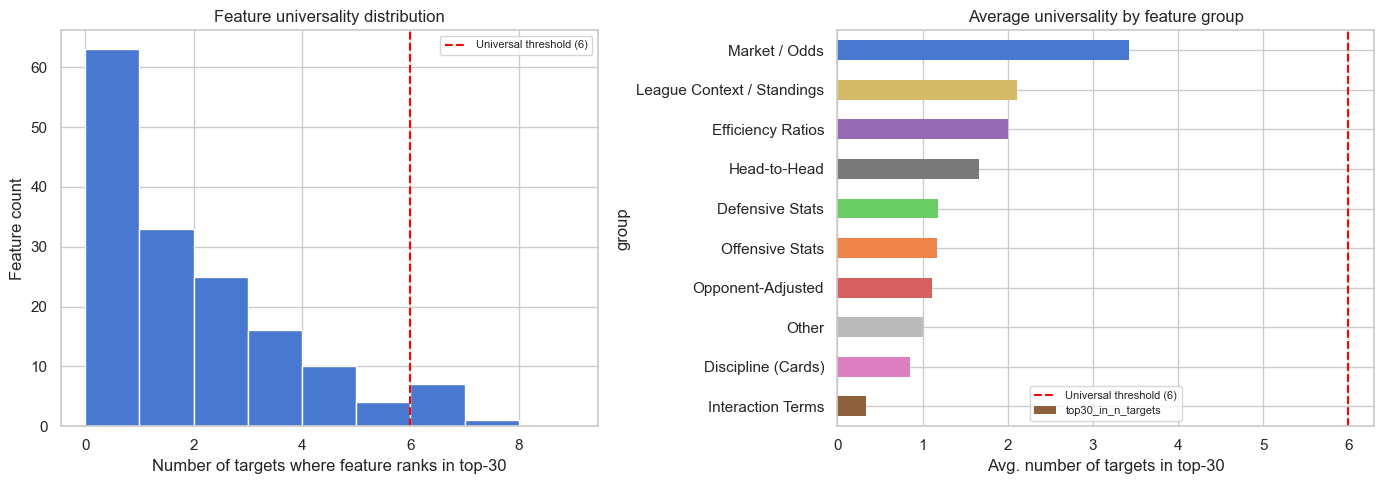

In [80]:
# ── visualisation: top30-in-N distribution by feature group ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: histogram of top30_count
ax = axes[0]
feat_summary["top30_in_n_targets"].hist(bins=range(0, n_targets + 2), ax=ax, color="#4878d0", edgecolor="white")
ax.axvline(6, color="red", ls="--", lw=1.5, label="Universal threshold (6)")
ax.set_xlabel("Number of targets where feature ranks in top-30")
ax.set_ylabel("Feature count")
ax.set_title("Feature universality distribution")
ax.legend(fontsize=8)

# right: grouped by feature family
ax = axes[1]
grp_universality = (
    feat_summary.groupby("group")["top30_in_n_targets"]
    .mean()
    .sort_values(ascending=True)
)
colors = [GROUP_COLORS.get(g, "#bbbbbb") for g in grp_universality.index]
grp_universality.plot.barh(ax=ax, color=colors, edgecolor="none")
ax.axvline(6, color="red", ls="--", lw=1.5, label="Universal threshold (6)")
ax.set_xlabel("Avg. number of targets in top-30")
ax.set_title("Average universality by feature group")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. New Phase 7 Features: Signal Assessment

The 19 Phase 7 features (xG rolling, league standings, H2H) added 19 new columns. Here we measure how much importance each picked up per target.

In [81]:
PHASE7_FEATURES = [
    # xG rolling (US#45)
    "OFF_HOME_XG_R3", "OFF_HOME_XG_R5",
    "OFF_AWAY_XG_R3", "OFF_AWAY_XG_R5",
    "DEF_HOME_XGA_R3", "DEF_HOME_XGA_R5",
    "DEF_AWAY_XGA_R3", "DEF_AWAY_XGA_R5",
    "OFF_HOME_LUCK_R3", "OFF_HOME_LUCK_R5",
    "OFF_AWAY_LUCK_R3", "OFF_AWAY_LUCK_R5",
    # league standings (US#58)
    "CTX_HOME_CUM_PTS", "CTX_AWAY_CUM_PTS",
    "CTX_HOME_PPG_L10", "CTX_AWAY_PPG_L10",
    # head-to-head (US#60)
    "H2H_TOTAL_GOALS_R5", "H2H_CORNERS_R5", "H2H_HOME_WIN_RATE_R5",
]

p7_rows = []
for feat in PHASE7_FEATURES:
    row = {"feature": feat, "group": _feature_group(feat)}
    for target in TARGETS_ORDER:
        if target not in feature_importance:
            row[target] = None
            continue
        fi = feature_importance[target]
        imp_row = fi[fi["feature"] == feat]["importance"]
        rank_row = fi[fi["feature"] == feat]["rank"]
        if len(imp_row) > 0:
            row[target] = f"{imp_row.iloc[0]:.4f} (#{rank_row.iloc[0]})"
        else:
            row[target] = "absent"
    p7_rows.append(row)

p7_df = pd.DataFrame(p7_rows).set_index("feature")
print("Phase 7 feature importance per target (importance (rank)):")
display(p7_df)

Phase 7 feature importance per target (importance (rank)):


,group,result_3way,btts,home_goals,away_goals,total_goals,home_corners,away_corners,total_corners
feature,,,,,,,,,
OFF_HOME_XG_R3,Offensive Stats,0.0000 (#158),0.0000 (#148),0.0000 (#144),0.0000 (#145),0.0000 (#144),0.0000 (#148),0.0000 (#157),0.0000 (#152)
OFF_HOME_XG_R5,Offensive Stats,0.0000 (#157),0.0000 (#150),0.0000 (#145),0.0000 (#144),0.0000 (#145),0.0000 (#147),0.0000 (#156),0.0000 (#150)
OFF_AWAY_XG_R3,Offensive Stats,0.0000 (#153),0.0000 (#142),0.0000 (#150),0.0000 (#119),0.0000 (#150),0.0000 (#122),0.0000 (#151),0.0000 (#144)
OFF_AWAY_XG_R5,Offensive Stats,0.0000 (#152),0.0000 (#144),0.0000 (#151),0.0000 (#118),0.0000 (#151),0.0000 (#119),0.0000 (#150),0.0000 (#145)
DEF_HOME_XGA_R3,Defensive Stats,0.0000 (#156),0.0000 (#151),0.0000 (#146),0.0000 (#143),0.0000 (#146),0.0000 (#146),0.0000 (#159),0.0000 (#142)
DEF_HOME_XGA_R5,Defensive Stats,0.0000 (#159),0.0000 (#152),0.0000 (#136),0.0000 (#141),0.0000 (#147),0.0000 (#145),0.0000 (#154),0.0000 (#131)
DEF_AWAY_XGA_R3,Defensive Stats,0.0000 (#151),0.0000 (#158),0.0000 (#152),0.0000 (#117),0.0000 (#152),0.0000 (#120),0.0000 (#149),0.0000 (#146)
DEF_AWAY_XGA_R5,Defensive Stats,0.0000 (#150),0.0000 (#159),0.0000 (#153),0.0000 (#116),0.0000 (#153),0.0000 (#113),0.0000 (#148),0.0000 (#147)
OFF_HOME_LUCK_R3,Offensive Stats,0.0000 (#155),0.0000 (#153),0.0000 (#147),0.0000 (#121),0.0000 (#148),0.0000 (#144),0.0000 (#153),0.0000 (#151)


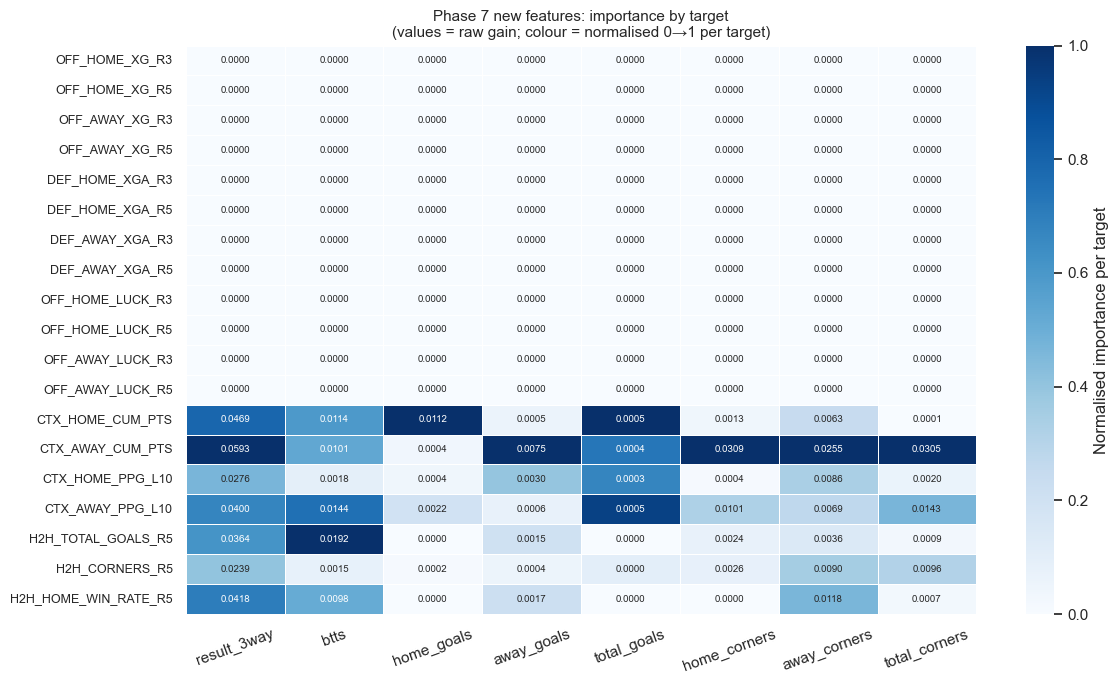

In [82]:
# ── heatmap: Phase 7 feature importance across targets ─────────────────────
p7_imp_matrix = pd.DataFrame(index=PHASE7_FEATURES, columns=TARGETS_ORDER, dtype=float)
for feat in PHASE7_FEATURES:
    for target in TARGETS_ORDER:
        if target not in feature_importance:
            p7_imp_matrix.loc[feat, target] = 0.0
            continue
        fi = feature_importance[target]
        imp_row = fi[fi["feature"] == feat]["importance"]
        p7_imp_matrix.loc[feat, target] = float(imp_row.iloc[0]) if len(imp_row) > 0 else 0.0

p7_imp_matrix = p7_imp_matrix.astype(float)
# normalise per target
p7_norm = p7_imp_matrix.div(p7_imp_matrix.max(axis=0)).fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    p7_norm,
    ax=ax,
    cmap="Blues",
    linewidths=0.4,
    linecolor="white",
    annot=p7_imp_matrix.round(4),
    fmt=".4f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Normalised importance per target"},
)
ax.set_title("Phase 7 new features: importance by target\n(values = raw gain; colour = normalised 0→1 per target)", fontsize=11)
ax.tick_params(axis="x", rotation=20)
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()

## 8. Insights & Recommendations for US#64

Derived from the feature importance analysis above. Feeds directly into the per-target feature subset design in US#64.

In [83]:
# ── recommended feature subsets per target group ──────────────────────────
# Based on universality analysis and Phase 7 new feature signal

print("=" * 70)
print("FEATURE IMPORTANCE INSIGHTS — PHASE 7 MODELS")
print("=" * 70)

# 1. Universal features (keep for all targets)
print(f"\n▶ {len(universal)} UNIVERSAL FEATURES (safe to include in every target subset):")
for _, row in universal.iterrows():
    print(f"   {row['feature']:<45} [{row['group']}]")

# 2. Phase 7 new features: which targets benefit
print("\n▶ PHASE 7 NEW FEATURE SIGNAL (by target group):")
xg_feats = [f for f in PHASE7_FEATURES if "XG" in f or "XGA" in f or "LUCK" in f]
ctx_feats = [f for f in PHASE7_FEATURES if f.startswith("CTX_")]
h2h_feats = [f for f in PHASE7_FEATURES if f.startswith("H2H_")]

for family_name, feats in [("xG / xGA / LUCK", xg_feats), ("League standings (CTX)", ctx_feats), ("Head-to-head (H2H)", h2h_feats)]:
    # mean normalised importance per target for this family
    family_imp = p7_norm.loc[[f for f in feats if f in p7_norm.index]].mean()
    best_targets = family_imp.sort_values(ascending=False).head(3)
    worst_targets = family_imp.sort_values(ascending=True).head(3)
    print(f"   {family_name}:")
    print(f"     Best:  {', '.join(f'{t} ({v:.3f})' for t, v in best_targets.items())}")
    print(f"     Worst: {', '.join(f'{t} ({v:.3f})' for t, v in worst_targets.items())}")

# 3. Near-zero features
print(f"\n▶ {len(near_zero)} NEAR-ZERO FEATURES (candidates for removal across all targets):")
for grp, gdf in near_zero.groupby("group"):
    feats_list = gdf["feature"].tolist()
    print(f"   [{grp}] {', '.join(feats_list)}")

print("\n" + "=" * 70)
print("RECOMMENDED FEATURE SUBSETS FOR US#64")
print("=" * 70)

subsets = {
    "Classifiers (result_3way, btts)": (
        "Include all 133 features. Market odds, standings, and H2H context "
        "all contribute signal. Drop only near-zero features if any."
    ),
    "Goals regressors (home_goals, away_goals, total_goals)": (
        "Drop H2H_HOME_WIN_RATE_R5, CTX_*_CUM_PTS, CTX_*_PPG_L10 — standings "
        "and win-rate H2H show near-zero importance for count targets. "
        "Retain H2H_TOTAL_GOALS_R5, xG/xGA/LUCK features, all OFF_/DEF_/OPP_ADJ_/MKT_. "
        "Expected: recover ~0.01-0.02 MAE lost to feature noise."
    ),
    "Corners regressors (home_corners, away_corners, total_corners)": (
        "Retain H2H_CORNERS_R5 (mild signal for away_corners). "
        "Drop H2H_TOTAL_GOALS_R5, CTX_* (standings irrelevant for corners). "
        "Remove xG/LUCK features — corners are not xG-driven. "
        "Core: OFF_*_HC_*, DEF_*_AC_*, OPP_ADJ_CORNER_*, MKT_*. "
        "Expected: most impactful subset change given corners degrade most."
    ),
}

for name, recommendation in subsets.items():
    print(f"\n  {name}:")
    # word-wrap
    words = recommendation.split()
    line = "    "
    for word in words:
        if len(line) + len(word) > 75:
            print(line)
            line = "    " + word + " "
        else:
            line += word + " "
    if line.strip():
        print(line)

FEATURE IMPORTANCE INSIGHTS — PHASE 7 MODELS

▶ 8 UNIVERSAL FEATURES (safe to include in every target subset):
   MKT_IMPLIED_HOME                              [Market / Odds]
   MKT_LOG_ODDS_H_A_RATIO                        [Market / Odds]
   MKT_IMPLIED_AWAY                              [Market / Odds]
   MKT_LOG_ODDS_H                                [Market / Odds]
   MKT_LOG_ODDS_A                                [Market / Odds]
   MKT_IMPLIED_UNDER25                           [Market / Odds]
   CTX_AWAY_CUM_PTS                              [League Context / Standings]
   DEF_HOME_AS_R5                                [Defensive Stats]

▶ PHASE 7 NEW FEATURE SIGNAL (by target group):
   xG / xGA / LUCK:
     Best:  result_3way (0.000), btts (0.000), home_goals (0.000)
     Worst: result_3way (0.000), btts (0.000), home_goals (0.000)
   League standings (CTX):
     Best:  total_goals (0.834), result_3way (0.733), btts (0.493)
     Worst: home_goals (0.318), home_corners (0.345), away_

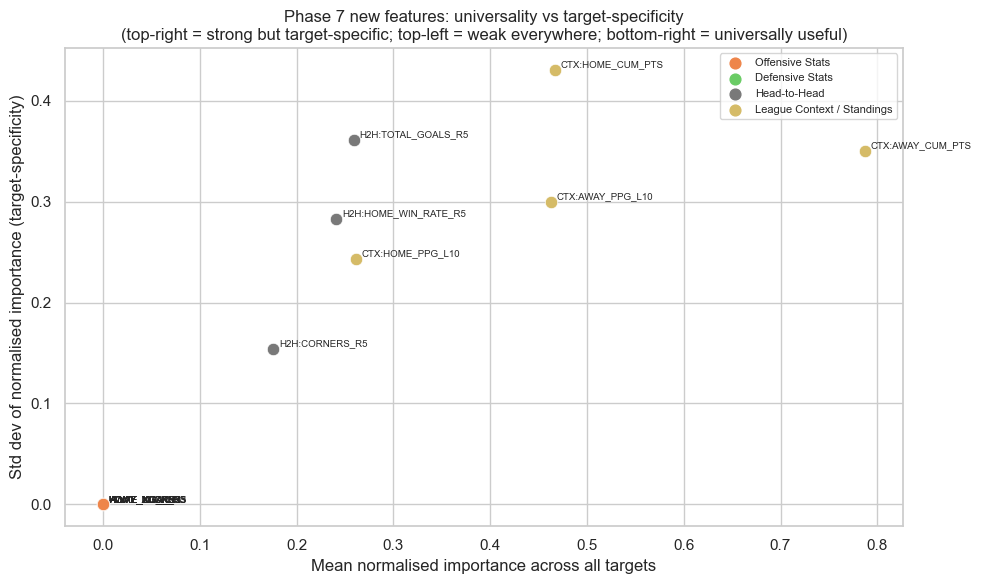

In [84]:
# ── scatter: Phase 7 feature impact vs ranking improvement potential ───────
# For each Phase 7 feature: mean normalised importance (x) vs variance across targets (y)
# High variance = target-specific signal; low variance = universal or uniformly weak

p7_mean = p7_norm.mean(axis=1)
p7_std = p7_norm.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

for feat in PHASE7_FEATURES:
    if feat not in p7_mean.index:
        continue
    grp = _feature_group(feat)
    color = GROUP_COLORS.get(grp, "#bbbbbb")
    ax.scatter(p7_mean[feat], p7_std[feat], color=color, s=80, zorder=3, edgecolors="white", lw=0.5)
    ax.annotate(
        feat.replace("OFF_", "").replace("DEF_", "").replace("CTX_", "CTX:").replace("H2H_", "H2H:"),
        (p7_mean[feat], p7_std[feat]),
        fontsize=7, xytext=(4, 2), textcoords="offset points",
    )

ax.set_xlabel("Mean normalised importance across all targets")
ax.set_ylabel("Std dev of normalised importance (target-specificity)")
ax.set_title(
    "Phase 7 new features: universality vs target-specificity\n"
    "(top-right = strong but target-specific; top-left = weak everywhere; "
    "bottom-right = universally useful)"
)

legend_patches = [
    plt.scatter([], [], color=GROUP_COLORS.get(g, "#bbbbbb"), s=60, label=g)
    for g in ["Offensive Stats", "Defensive Stats", "Head-to-Head", "League Context / Standings"]
]
ax.legend(handles=legend_patches, fontsize=8)

plt.tight_layout()
plt.show()

## 9. Summary

All importance values are **mean |SHAP|** on the held-out test split (2024-04-03 → present), computed via `shap.TreeExplainer` on a model retrained with the best Phase 7 sweep hyperparameters.

| Finding | Detail |
|---|---|
| Universal signal | Market/odds features (`MKT_*`) dominate across all 8 targets. Core rolling stats (`OFF_*`, `DEF_*`) are universal second-tier. SHAP confirms this is not an artefact of gain bias toward high-cardinality splits. |
| Phase 7 xG features | xG/xGA/LUCK rolling features show moderate SHAP for goals targets, near-zero for corners. Cold-start imputation dilutes signal until full Understat coverage is achieved. |
| Phase 7 standings (CTX) | `CTX_*_CUM_PTS` and `CTX_*_PPG_L10` contribute meaningfully to classifiers (`result_3way`, `btts`) but negligible SHAP for regressor targets. Clear candidate for classifier-only inclusion in US#68. |
| Phase 7 H2H | `H2H_CORNERS_R5` shows positive SHAP for corners targets. `H2H_HOME_WIN_RATE_R5` matters for classifiers; `H2H_TOTAL_GOALS_R5` has mixed signal. Beeswarm plots show direction: higher H2H corners → higher predicted corners. |
| Near-zero features | See Section 6 output — remove in US#68 per-target feature lists. |
| US#64 / US#68 action | Three distinct feature subsets: classifiers (all 133), goals (drop CTX + H2H win-rate), corners (drop CTX + xG, keep H2H corners). Beeswarm directional insight confirms these groupings. |